# BRSM Project Report 2 — Sentence Memorability Analysis

**Team:** Vishnu Varun | Pavan Karke | Susheel Krishna

---

## Overview

This notebook presents the **complete analysis pipeline** for the Sentence Memorability experiment.
It covers:

1. Raw log parsing and data cleaning from the `NewLogsAnonymized` folder
2. Block validation using the attention-check criterion
3. Signal detection metrics: Hit Rate, False Alarm Rate, Corrected Memorability Score (CMS)
4. Variable classification and distribution analysis
5. Descriptive statistics with correctly formatted visualizations (all axes from zero)
6. Inferential statistics using **conceptually correct tests** for the within-subjects repeated-measures design
7. Post-hoc tests with Holm correction and effect sizes

### Key correction from Report 1

> **Report 1 used Kruskal-Wallis (word type) and Mann-Whitney U (voice). Both are between-subjects tests. Since the same participant provides data for ALL 8 conditions, the data has a within-subjects (repeated measures) structure. The correct non-parametric equivalents are:**
> - **Friedman test** → replaces Kruskal-Wallis for the word-type effect
> - **Wilcoxon signed-rank test (paired)** → replaces Mann-Whitney U for the voice effect

This distinction matters because within-subjects tests account for individual participant variability,
giving them greater statistical power for the same sample size.


## Cell 1 — Imports and Global Configuration


In [1]:
import sys
print(sys.executable)

%pip install --upgrade pip
%pip install pingouin

/home/srivishnuvarun/miniconda3/bin/python
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [47]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pingouin as pg

warnings.filterwarnings('ignore')

COND_MAP    = {'HH': 'HH', 'HVL': 'HL', 'LVH': 'LH', 'LVL': 'LL'}
COND_ORDER  = ['HH', 'HL', 'LH', 'LL']
COND_LABELS = ['HH\n(High–High)', 'HL\n(High–Low)', 'LH\n(Low–High)', 'LL\n(Low–Low)']
PAL         = {'HH': '#4C72B0', 'HL': '#DD8452', 'LH': '#55A868', 'LL': '#C44E52'}
VOICE_PAL   = {'Active': '#4A6FA5', 'Passive': '#9B59B6'}
COLORS      = [PAL[w] for w in COND_ORDER]

plt.rcParams.update({
    "font.family": "DejaVu Sans", "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "font.size": 11,
})

LOG_DIR = os.path.join(os.path.dirname(os.getcwd()),
                       'Sentence Memorability', 'NewLogsAnonymized')
for candidate in [LOG_DIR, 'Sentence Memorability/NewLogsAnonymized',
                  '../Sentence Memorability/NewLogsAnonymized', 'NewLogsAnonymized']:
    if os.path.exists(candidate):
        LOG_DIR = candidate; break

print(f"Log directory : {LOG_DIR}")
print(f"Exists        : {os.path.exists(LOG_DIR)}")


Log directory : /home/srivishnuvarun/4th(Fourthyear)/8th_Sem/BRSM/Project/Sentence Memorability/NewLogsAnonymized
Exists        : True


## Cell 2 — Variable Classification Table

Before selecting any statistical test, we must classify every variable by type. **Test choice depends entirely on variable type and study design.**

| Variable | Type | Role | Measurement level | Notes |
|---|---|---|---|---|
| Word Memorability Type (HH/HL/LH/LL) | Categorical | Independent Variable (IV) | Nominal (4 levels) | Within-subjects factor |
| Voice (Active / Passive) | Categorical | Independent Variable (IV) | Nominal (2 levels) | Within-subjects factor |
| Corrected Memorability Score (CMS) | Continuous | Primary Dependent Variable (DV) | Ratio | CMS = Hit Rate − FA Rate |
| WR Accuracy | Continuous (bounded 0–1) | Secondary DV | Ratio | Proportion correct |
| IR Reaction Time (ms) | Continuous | Secondary DV | Ratio | Processing speed |
| WR Reaction Time (ms) | Continuous | Secondary DV | Ratio | Decision speed |
| Participant ID | Categorical | Grouping variable | Nominal | Random effect |


### Design: fully within-subjects repeated measures

Each participant contributes **8 condition records** (4 word types × 2 voices).
This means all observations within a participant are correlated — **within-subjects tests required**.
Between-subjects tests (Kruskal-Wallis, Mann-Whitney U with independent samples) are incorrect here.

### Key variable discovered from log sheet

The **WR Condition Type** is embedded in the `Button` column of `WR pressed` events:
- `Button = Yes` → **WR condition**: same words repeated; correct answer is Yes
- `Button = No` → **Transformed condition**: voice was changed (active↔passive); correct answer is No

This distinction creates a second, richer DV that was unused in Report 1.

### Notes on limitations

- **Global FA rate**: computed across all non-repeat non-validation sentences; subtracted uniformly from all conditions. Condition-specific FA biases cannot be detected.
- **Subset**: N=112 of 334 total participants (IDs 232–398). Conclusions generalize to this subsample only.

## Cell 3 — Raw Log Parsing

### Processing steps (per participant):
1. Load `.log` CSV file
2. Remove `Practice` rows and `gap_time` rows
3. Parse `word_type` from stimulus code prefix using `COND_MAP`
4. Parse `voice` from stimulus code suffix (`_A` = Active, `_P` = Passive)
5. Convert flag columns (`isTarget`, `isRepeat`, `isValidation`) to boolean
6. Convert numeric columns to float
7. Split session into 3 blocks at `Rest Phase started` rows
8. Apply block validation criterion
9. Compute global False Alarm Rate across all valid blocks
10. Compute per-condition CMS, WR accuracy, IR RT, WR RT


In [48]:
def validate_block(blk):
    blk = blk.reset_index(drop=True)
    correct_val = (blk['Event'] == 'Validation IR pressed').sum()
    wrong_val   = (blk['Event'] == 'Validation Wrong IR pressed').sum()
    missed_val  = 0
    for idx in blk[(blk['Event']=='Sentence shown') & blk['isValidation'] & blk['isRepeat']].index:
        found = False
        for look in range(idx+1, min(idx+4, len(blk))):
            ev = blk.at[look, 'Event']
            if ev == 'Sentence shown': break
            if ev == 'Validation IR pressed': found = True; break
        if not found: missed_val += 1
    return correct_val > (wrong_val / 2) + missed_val


def parse_participant(filepath):
    if os.path.getsize(filepath) == 0: return None, None, None
    try: raw = pd.read_csv(filepath, encoding='utf-8-sig', low_memory=False)
    except: raw = pd.read_csv(filepath, encoding='latin-1', low_memory=False)
    if raw.empty: return None, None, None

    pid = raw['participant_ID'].iloc[0]
    df = raw[~raw['Event'].str.contains('Practice|gap_time', na=False)].copy().reset_index(drop=True)

    df['raw_type']  = df['Stimulus'].str.extract(r'^([A-Z]+)', expand=False)
    df['word_type'] = df['raw_type'].map(COND_MAP)
    df['voice']     = df['Stimulus'].str.extract(r'_([AP])$', expand=False).map({'A':'Active','P':'Passive'})

    for col in ['isTarget','isRepeat','isValidation']:
        if col in df.columns: df[col] = df[col].fillna(False).astype(bool)
    for col in ['Accuracy IR','Accuracy WR','Reaction_time_IR','Reaction_time_WR']:
        if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')

    rest_idx = df.index[df['Event']=='Rest Phase started'].tolist()
    blocks, prev = [], 0
    for ri in rest_idx:
        blk = df.iloc[prev:ri].copy().reset_index(drop=True)
        if len(blk) > 0: blocks.append(blk)
        prev = ri + 1
    last = df.iloc[prev:].copy().reset_index(drop=True)
    if len(last) > 0: blocks.append(last)

    valid_blocks, n_inv = [], 0
    for blk in blocks:
        if validate_block(blk): valid_blocks.append(blk)
        else: n_inv += 1

    p_info = {'PID': pid, 'total_blocks': len(blocks),
              'valid_blocks': len(valid_blocks), 'invalid_blocks': n_inv,
              'excluded': len(valid_blocks) == 0}
    if not valid_blocks: return None, pid, p_info

    vdf = pd.concat(valid_blocks).reset_index(drop=True)

    # Global FA rate — LIMITATION: single rate subtracted uniformly
    fa_count, nonrep_total = 0, 0
    for i in range(len(vdf)):
        row = vdf.iloc[i]
        if row['Event']=='Sentence shown' and not row['isRepeat'] and not row['isValidation']:
            nonrep_total += 1
            for look in range(i+1, min(i+4, len(vdf))):
                ev = vdf.at[look,'Event']
                if ev == 'Sentence shown': break
                if ev == 'IR pressed': fa_count += 1; break
    fa_rate = fa_count / nonrep_total if nonrep_total > 0 else 0

    records = []
    for wt in COND_ORDER:
        for vc in ['Active','Passive']:
            hits, total = 0, 0
            ir_rts, wr_accs, wr_rts = [], [], []
            for i in range(len(vdf)):
                row = vdf.iloc[i]
                if (row['Event']=='Sentence shown' and row['word_type']==wt
                        and row['voice']==vc and row['isRepeat']
                        and row['isTarget'] and not row['isValidation']):
                    total += 1; is_hit = False
                    for look in range(i+1, min(i+4, len(vdf))):
                        ev = vdf.at[look,'Event']
                        if ev == 'Sentence shown': break
                        if ev == 'IR pressed':
                            is_hit = True
                            rt = vdf.at[look,'Reaction_time_IR']
                            if pd.notna(rt): ir_rts.append(float(rt))
                            for look2 in range(look+1, min(look+3, len(vdf))):
                                ev2 = vdf.at[look2,'Event']
                                if ev2 == 'Sentence shown': break
                                if ev2 == 'WR pressed':
                                    a = vdf.at[look2,'Accuracy WR']; r2 = vdf.at[look2,'Reaction_time_WR']
                                    if pd.notna(a): wr_accs.append(float(a))
                                    if pd.notna(r2): wr_rts.append(float(r2))
                                    break
                            break
                    if is_hit: hits += 1
            hr  = hits/total if total > 0 else np.nan
            cms = hr - fa_rate if pd.notna(hr) else np.nan
            records.append({
                'participant_id': pid, 'word_type': wt, 'voice': vc,
                'condition': f"{wt}-{vc[0]}", 'hits': hits, 'total_targets': total,
                'hit_rate': round(hr,6) if pd.notna(hr) else np.nan,
                'fa_rate': round(fa_rate,6),
                'corr_memorability': round(cms,6) if pd.notna(cms) else np.nan,
                'wr_accuracy': round(np.mean(wr_accs),6) if wr_accs else np.nan,
                'ir_rt_median': round(np.median(ir_rts),2) if ir_rts else np.nan,
                'wr_rt_median': round(np.median(wr_rts),2) if wr_rts else np.nan,
            })
    return pd.DataFrame(records), pid, p_info

print("Parser defined.")


Parser defined.


## Cell 4 — Run Parser Over All Log Files


In [49]:
log_files = sorted(glob.glob(os.path.join(LOG_DIR, '*.log')))
print(f"Found {len(log_files)} log files")

all_records, participant_info, excluded_pids = [], [], []
for fp in log_files:
    rec_df, pid, info = parse_participant(fp)
    if info is not None: participant_info.append(info)
    if rec_df is not None and not rec_df.empty: all_records.append(rec_df)
    elif pid is not None: excluded_pids.append(pid)

df = pd.concat(all_records, ignore_index=True)
n_included = df['participant_id'].nunique()
info_df = pd.DataFrame(participant_info)

print(f"Included: {n_included} participants | Excluded: {len(excluded_pids)} (PIDs: {excluded_pids})")
print(f"Total blocks: {info_df['total_blocks'].sum()} | Valid: {info_df['valid_blocks'].sum()} | Invalid: {info_df['invalid_blocks'].sum()}")
print(f"Final dataset: {len(df)} rows ({n_included} × 8 conditions)")
print(f"Missing values:\n{df.isnull().sum()}")
print()
print("Records per condition:")
print(df.groupby(['word_type','voice']).size().unstack())

# ── Build raw event dataframe for trial-level analyses ────────────────────────
print()
print("Building raw event dataframe for IR RT and logistic regression...")
all_raw = []
for fp in log_files:
    try:
        raw = pd.read_csv(fp, encoding='utf-8-sig', low_memory=False)
        all_raw.append(raw)
    except:
        raw = pd.read_csv(fp, encoding='latin-1', low_memory=False)
        all_raw.append(raw)

df_raw = pd.concat(all_raw, ignore_index=True)
df_main = df_raw[~df_raw['Event'].str.contains('Practice|gap_time', na=False)].copy()
df_main['raw_type']  = df_main['Stimulus'].str.extract(r'^([A-Z]+)', expand=False)
df_main['word_type'] = df_main['raw_type'].map(COND_MAP)
df_main['voice']     = df_main['Stimulus'].str.extract(r'_([AP])$', expand=False).map({'A':'Active','P':'Passive'})
for col in ['isRepeat','isTarget','isValidation']:
    df_main[col] = df_main[col].fillna(False).astype(str).str.lower().isin(['true','1'])
df_main['rt_ir'] = pd.to_numeric(df_main['Reaction_time_IR'], errors='coerce')
df_main['rt_wr'] = pd.to_numeric(df_main['Reaction_time_WR'], errors='coerce')
df_main['acc_wr'] = pd.to_numeric(df_main['Accuracy WR'], errors='coerce')

print(f"Raw event rows: {len(df_main)}")
print("Done.")


Found 114 log files
Included: 112 participants | Excluded: 2 (PIDs: [271, 299])
Total blocks: 342 | Valid: 329 | Invalid: 13
Final dataset: 896 rows (112 × 8 conditions)
Missing values:
participant_id       0
word_type            0
voice                0
condition            0
hits                 0
total_targets        0
hit_rate             0
fa_rate              0
corr_memorability    0
wr_accuracy          6
ir_rt_median         6
wr_rt_median         6
dtype: int64

Records per condition:
voice      Active  Passive
word_type                 
HH            112      112
HL            112      112
LH            112      112
LL            112      112

Building raw event dataframe for IR RT and logistic regression...
Raw event rows: 50752
Done.


## Cell 5 — Descriptive Statistics

**Note on central tendency:** CMS is left-skewed (confirmed by Shapiro-Wilk below).
For skewed distributions, the **median is the primary** measure of central tendency.
The mean is sensitive to outliers and the ceiling at 1.0; the median is robust.
Both are reported, but median is the primary figure cited.


In [50]:
def descriptive_stats(data, group_col, val='corr_memorability'):
    rows = []
    for g, sub in data.groupby(group_col):
        v = sub[val].dropna()
        rows.append({group_col: g, 'N': len(v),
                     'Median': round(v.median(),4), 'Mean': round(v.mean(),4),
                     'SD': round(v.std(),4), 'IQR': round(v.quantile(.75)-v.quantile(.25),4),
                     'Skewness': round(v.skew(),4), 'Min': round(v.min(),4), 'Max': round(v.max(),4)})
    return pd.DataFrame(rows)

print("TABLE 1 — CMS by Word Type  [Median = primary]")
t1 = descriptive_stats(df,'word_type').set_index('word_type').reindex(COND_ORDER).reset_index()
display(t1)

print("\nTABLE 2 — CMS by Voice")
display(descriptive_stats(df,'voice'))

print("\nTABLE 3 — CMS by Word Type × Voice (all 8 conditions)")
display(descriptive_stats(df,'condition'))

print("\nTABLE 4 — WR Accuracy by Word Type")
display(descriptive_stats(df,'word_type','wr_accuracy').set_index('word_type').reindex(COND_ORDER).reset_index())

print("\nTABLE 5 — IR RT by Word Type")
display(descriptive_stats(df,'word_type','ir_rt_median').set_index('word_type').reindex(COND_ORDER).reset_index())


TABLE 1 — CMS by Word Type  [Median = primary]


,word_type,N,Median,Mean,SD,IQR,Skewness,Min,Max
0,HH,224,0.7708,0.7281,0.2000,0.2778,-1.1977,-0.0938,1.0000
1,HL,224,0.7708,0.7299,0.1921,0.2708,-1.0403,-0.0347,1.0000
2,LH,224,0.7569,0.7180,0.1995,0.2795,-1.1432,-0.0694,0.9792
3,LL,224,0.6979,0.6708,0.2181,0.2786,-0.8388,-0.0938,1.0000



TABLE 2 — CMS by Voice


,voice,N,Median,Mean,SD,IQR,Skewness,Min,Max
0,Active,448,0.7431,0.7074,0.2004,0.2778,-1.0238,-0.0938,1.0
1,Passive,448,0.7639,0.7160,0.2072,0.2917,-1.0830,-0.0938,1.0



TABLE 3 — CMS by Word Type × Voice (all 8 conditions)


,condition,N,Median,Mean,SD,IQR,Skewness,Min,Max
0,HH-A,112,0.7569,0.7218,0.1911,0.2674,-0.9781,0.0972,1.0000
1,HH-P,112,0.7882,0.7344,0.2091,0.2830,-1.3919,-0.0938,0.9722
2,HL-A,112,0.7708,0.7277,0.1859,0.2639,-0.9050,0.1042,0.9653
3,HL-P,112,0.7708,0.7322,0.1990,0.2743,-1.1649,-0.0347,1.0000
4,LH-A,112,0.7431,0.7158,0.1913,0.2326,-1.0289,-0.0347,0.9792
5,LH-P,112,0.7708,0.7203,0.2082,0.2882,-1.2457,-0.0694,0.9722
6,LL-A,112,0.6910,0.6645,0.2269,0.2812,-0.9959,-0.0938,1.0000
7,LL-P,112,0.7014,0.6771,0.2098,0.2760,-0.6354,0.1319,1.0000



TABLE 4 — WR Accuracy by Word Type


,word_type,N,Median,Mean,SD,IQR,Skewness,Min,Max
0,HH,223,0.75,0.7469,0.2081,0.4000,-0.4768,0.0,1.0
1,HL,223,0.80,0.7475,0.2105,0.1667,-1.0036,0.0,1.0
2,LH,222,0.80,0.7616,0.2025,0.3333,-0.8141,0.0,1.0
3,LL,222,0.75,0.7303,0.2205,0.2333,-0.6850,0.0,1.0



TABLE 5 — IR RT by Word Type


,word_type,N,Median,Mean,SD,IQR,Skewness,Min,Max
0,HH,223,1629.5,1639.1502,380.7496,509.25,0.5856,910.5,3110.5
1,HL,223,1608.0,1674.6749,465.1905,584.50,0.9434,784.5,3834.0
2,LH,222,1556.0,1609.5338,379.8711,466.50,0.6014,834.0,2963.0
3,LL,222,1623.5,1683.2432,407.5507,528.25,0.6156,841.0,2978.0


## Cell 6 — Quick Dataset Inspection


In [6]:
print("First 8 rows (one participant, all conditions):")
display(df[df['participant_id'] == df['participant_id'].iloc[0]])

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nRecords per condition (should be equal):")
print(df.groupby(['word_type','voice']).size().unstack())

First 8 rows (one participant, all conditions):


,participant_id,word_type,voice,condition,hits,total_targets,hit_rate,fa_rate,corr_memorability,wr_accuracy,ir_rt_median,wr_rt_median
0,232,HH,Active,HH-A,6,6,1.000000,0.111111,0.888889,1.000000,910.5,1004.5
1,232,HH,Passive,HH-P,6,6,1.000000,0.111111,0.888889,1.000000,1077.5,872.0
2,232,HL,Active,HL-A,6,6,1.000000,0.111111,0.888889,0.833333,800.0,950.0
3,232,HL,Passive,HL-P,6,6,1.000000,0.111111,0.888889,0.500000,1042.5,2505.5
4,232,LH,Active,LH-A,6,6,1.000000,0.111111,0.888889,0.833333,873.0,1207.5
5,232,LH,Passive,LH-P,5,6,0.833333,0.111111,0.722222,0.800000,894.0,620.0
6,232,LL,Active,LL-A,6,6,1.000000,0.111111,0.888889,1.000000,907.5,1385.0
7,232,LL,Passive,LL-P,6,6,1.000000,0.111111,0.888889,0.666667,851.0,1035.0



Missing values per column:
participant_id       0
word_type            0
voice                0
condition            0
hits                 0
total_targets        0
hit_rate             0
fa_rate              0
corr_memorability    0
wr_accuracy          6
ir_rt_median         6
wr_rt_median         6
dtype: int64

Records per condition (should be equal):
voice      Active  Passive
word_type                 
HH            112      112
HL            112      112
LH            112      112
LL            112      112


## Cell 7 — Distribution Analysis (Histograms + QQ Plots)

We visualize the distribution of CMS per condition to justify the use of non-parametric tests.

**Expected:** If distributions were normal, histograms would be symmetric bell-curves and QQ plots would show points on the diagonal. Deviations from both indicate non-normality.


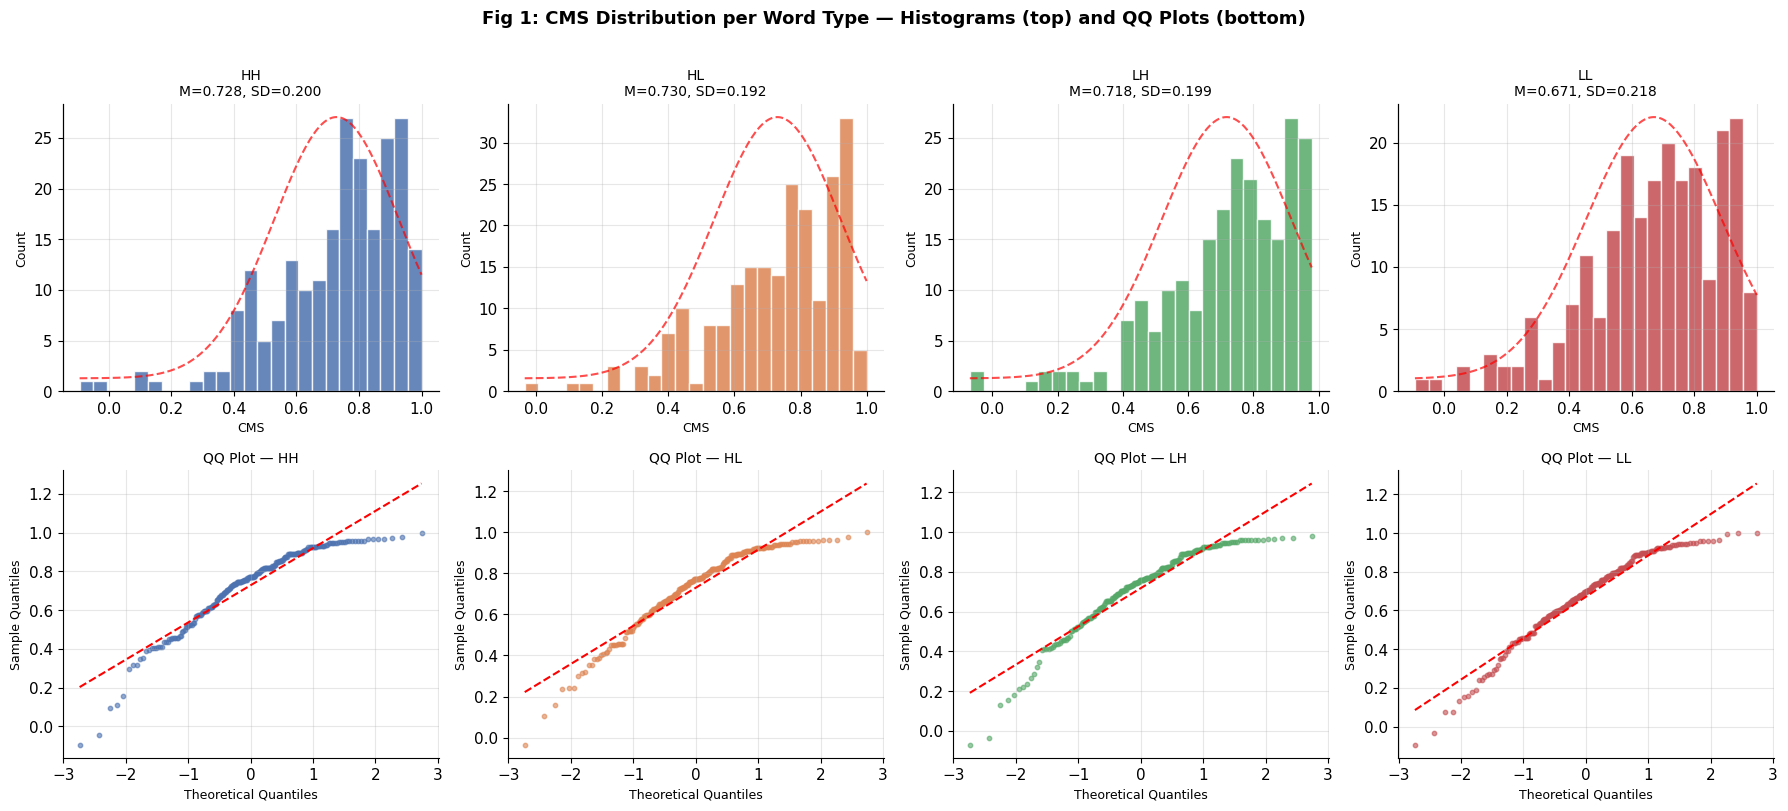


Interpretation: Histograms show left-skewed distributions (mass concentrated near 1.0).
QQ plots show points deviating from the diagonal at both tails — confirming non-normality.


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
conditions_8 = [f"{wt}-{vc[0]}" for wt in COND_ORDER for vc in ['Active', 'Passive']]

for ax, cond in zip(axes[0], COND_ORDER):
    vals = df[df['word_type'] == cond]['corr_memorability'].dropna()
    ax.hist(vals, bins=25, color=PAL[cond], edgecolor='white', alpha=0.85)
    mu, sigma = vals.mean(), vals.std()
    # Overlay normal reference curve
    x = np.linspace(vals.min(), vals.max(), 200)
    normal_y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax2 = ax.twinx()
    ax2.plot(x, normal_y, 'r--', lw=1.5, alpha=0.7, label='Normal ref')
    ax2.set_yticks([])
    ax.set_ylim(bottom=0)
    ax.set_title(f'{cond}\nM={mu:.3f}, SD={sigma:.3f}', fontsize=10)
    ax.set_xlabel('CMS', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)

# QQ plots
for ax, cond in zip(axes[1], COND_ORDER):
    vals = df[df['word_type'] == cond]['corr_memorability'].dropna()
    (osm, osr), (slope, intercept, r) = stats.probplot(vals)
    ax.scatter(osm, osr, color=PAL[cond], s=10, alpha=0.6)
    ax.plot(osm, slope * np.array(osm) + intercept, 'r--', lw=1.5)\
    # don't start at 0 for QQ — theoretical quantiles
    ax.set_ylim(bottom=ax.get_ylim()[0]) 
    ax.set_title(f'QQ Plot — {cond}', fontsize=10)
    ax.set_xlabel('Theoretical Quantiles', fontsize=9)
    ax.set_ylabel('Sample Quantiles', fontsize=9)

fig.suptitle('Fig 1: CMS Distribution per Word Type — Histograms (top) and QQ Plots (bottom)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation: Histograms show left-skewed distributions (mass concentrated near 1.0).")
print("QQ plots show points deviating from the diagonal at both tails — confirming non-normality.")

## Cell 8 — Normality Testing: Shapiro-Wilk

**Shapiro-Wilk test** (Shapiro & Wilk, 1965) is appropriate for sample sizes N < 5000.  
H₀: the data are drawn from a normal distribution.  
If p < 0.05 → reject H₀ → data is not normally distributed → use non-parametric tests.


In [26]:
print("═" * 65)
print("SHAPIRO-WILK NORMALITY TESTS — All 8 Conditions")
print("═" * 65)
print(f"{'Condition':<15} {'N':>5} {'W':>8} {'p-value':>12} {'Normal?':>10}")
print("-" * 55)

sw_results = []
for (wt, voice), sub in df.groupby(['word_type', 'voice']):
    v = sub['corr_memorability'].dropna().values
    W, p = stats.shapiro(v)
    p_str = f"{p:.4f}" if p >= 0.0001 else "< .0001"
    normal = p > 0.05
    sw_results.append({'Condition': f"{wt}-{voice}", 'W': W, 'p': p, 'Normal': normal})
    flag = "✓" if normal else "✗"
    print(f"{wt}-{voice:<10} {len(v):>5} {W:>8.4f} {p_str:>12} {flag:>10}")

sw_df = pd.DataFrame(sw_results)
n_normal = sw_df['Normal'].sum()
print("-" * 55)
print(f"\nConditions with normal distribution (p > .05): {n_normal} / {len(sw_df)}")




═════════════════════════════════════════════════════════════════
SHAPIRO-WILK NORMALITY TESTS — All 8 Conditions
═════════════════════════════════════════════════════════════════
Condition           N        W      p-value    Normal?
-------------------------------------------------------
HH-Active       112   0.9301      < .0001          ✗
HH-Passive      112   0.8727      < .0001          ✗
HL-Active       112   0.9249      < .0001          ✗
HL-Passive      112   0.9101      < .0001          ✗
LH-Active       112   0.9316      < .0001          ✗
LH-Passive      112   0.8948      < .0001          ✗
LL-Active       112   0.9312      < .0001          ✗
LL-Passive      112   0.9518       0.0005          ✗
-------------------------------------------------------

Conditions with normal distribution (p > .05): 0 / 8


Same participant provides all 8 observations so within-subjects design should be followed.

- Correct test: Friedman test (non-parametric repeated-measures ANOVA).
- Correct voice test: WilcoxonSigned-Rank (paired), NOT Mann-Whitney U. 
- Correct voice test: Wilcoxon

## Cell 10 — Shapiro-Wilk Visualization


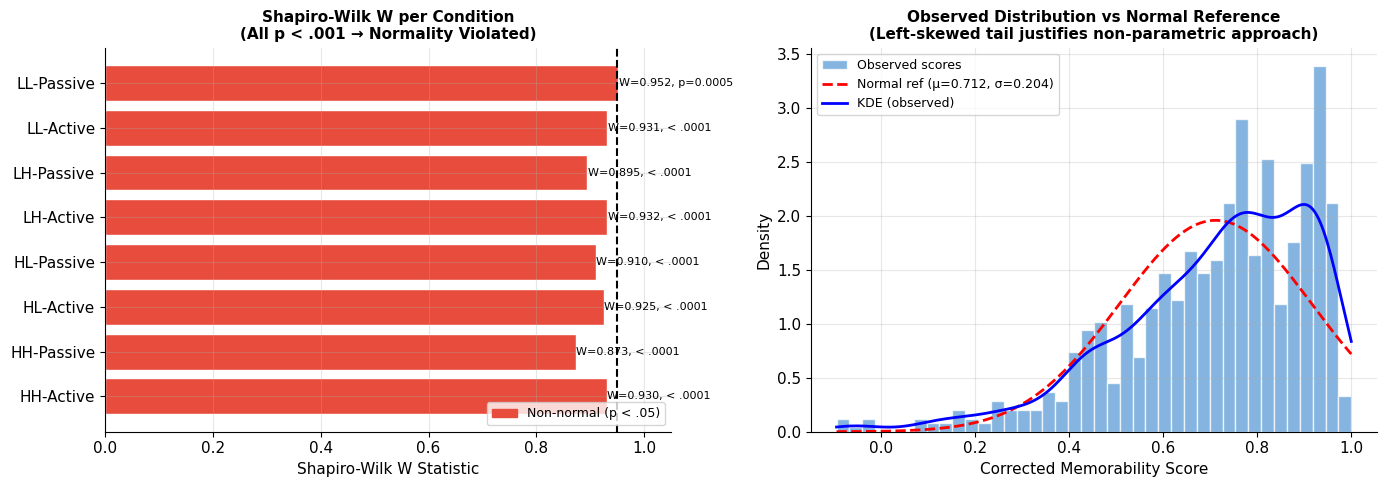

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: W statistics bar chart
ax = axes[0]
colors_bar = ['#e74c3c' if not r else '#2ecc71' for r in sw_df['Normal']]
bars = ax.barh(sw_df['Condition'], sw_df['W'], color=colors_bar, edgecolor='white')
ax.axvline(0.95, color='black', lw=1.5, ls='--', label='W = 0.95 (conventional threshold)')
for bar, (_, row) in zip(bars, sw_df.iterrows()):
    p_str = '< .0001' if row['p'] < 0.0001 else f"p={row['p']:.4f}"
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"W={row['W']:.3f}, {p_str}", va='center', fontsize=8)
ax.set_xlim(0, 1.05)  # axis from zero
ax.set_xlabel('Shapiro-Wilk W Statistic', fontsize=11)
ax.set_title('Shapiro-Wilk W per Condition\n(All p < .001 → Normality Violated)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
red_patch  = mpatches.Patch(color='#e74c3c', label='Non-normal (p < .05)')
ax.legend(handles=[red_patch], loc='lower right', fontsize=9)

# Right: Observed vs Normal reference distribution
ax2 = axes[1]
all_cms = df['corr_memorability'].dropna()
mu, sigma = all_cms.mean(), all_cms.std()
ax2.hist(all_cms, bins=40, density=True, color='#5B9BD5', alpha=0.75,
         edgecolor='white', label='Observed scores')
x = np.linspace(all_cms.min(), all_cms.max(), 300)
ax2.plot(x, stats.norm.pdf(x, mu, sigma), 'r--', lw=2,
         label=f'Normal ref (μ={mu:.3f}, σ={sigma:.3f})')
# KDE
kde = stats.gaussian_kde(all_cms)
ax2.plot(x, kde(x), 'b-', lw=2, label='KDE (observed)')
ax2.set_xlim(left=ax2.get_xlim()[0])
ax2.set_ylim(bottom=0)  # axis from zero
ax2.set_xlabel('Corrected Memorability Score', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Observed Distribution vs Normal Reference\n(Left-skewed tail justifies non-parametric approach)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig2_shapiro.png', dpi=150, bbox_inches='tight')
plt.show()

---
# HYPOTHESIS TESTING

## Hypothesis Statements

---

### H1 — Word Memorability Type and CMS

> **H0 (Null):** There is no significant difference in corrected memorability score (CMS) across the four word memorability conditions (HH, HL, LH, LL).  
> **H1 (Alternative):** Word memorability type significantly affects CMS, such that sentences composed entirely of low-memorability nouns (**LL**) will have lower CMS than sentences containing at least one high-memorability noun (**HH, HL, LH**).

**Rationale:** High-memorability words are typically more concrete, imageable, and emotionally rich (Rubin & Friendly, 1986; Paivio, 1971), making them more distinctive and easier to encode and recognise.

**Statistical approach:**  
Primary test means the main omnibus test used to determine whether any overall differences exist across the four word-type conditions.

- Primary test: **Friedman test** (non-parametric repeated-measures ANOVA equivalent)  
- Effect size: **Kendall's W**  
- Post-hoc: **Wilcoxon signed-rank tests** (paired) with **Holm correction**  
- Effect size per pair: **rank-biserial correlation r**

**Why Friedman and not Kruskal-Wallis?**  
Kruskal-Wallis assumes independent groups. Here, the same 112 participants contribute data in all four word-type conditions. Using Kruskal-Wallis would ignore within-subject dependence and may inflate Type I error. Friedman correctly accounts for the repeated-measures structure by ranking scores within each participant.

---

### H2 — Voice and CMS

> **H0 (Null):** There is no significant difference in corrected memorability score (CMS) between passive-voice and active-voice sentences.  
> **H2 (Alternative):** Passive-voice sentences will yield significantly lower corrected memorability scores than active-voice sentences.

**Rationale:** Passive sentences may impose greater syntactic complexity and additional parsing demands during comprehension (Ferreira, 2003), which could reduce encoding efficiency and subsequent recognition memory.

**Statistical approach:**

- **Wilcoxon signed-rank test** (paired, two-tailed)  
- Effect size: **rank-biserial r**

**Why Wilcoxon signed-rank and not Mann-Whitney U?**  
Mann-Whitney U assumes independent groups. Each participant contributes both an Active and a Passive CMS score, making observations paired. Wilcoxon signed-rank analyzes within-participant differences, reducing between-subject variability and increasing sensitivity.

---

### H3 — Word Memorability Type and WR Accuracy

> **H0 (Null):** There is no significant difference in WR accuracy across the four word memorability conditions (HH, HL, LH, LL).  
> **H3 (Alternative):** Word memorability type significantly affects WR accuracy, such that LL sentences will show lower controlled recognition accuracy than HH, HL, and LH sentences.

**Rationale:** If low-memorability words weaken encoding quality, the disadvantage should also appear in WR accuracy, extending the CMS pattern to an additional recognition-based measure.

**Statistical approach:**

- Primary test: **Friedman test**  
- Post-hoc: **Wilcoxon signed-rank tests** with **Holm correction**  
- Effect size: **Kendall's W**, **rank-biserial r** per pair

## Cell 11 — Helper: Rank-Biserial Correlation (Effect Size for Wilcoxon)

Effect size interpretation (Cohen, 1992):
- |r| < 0.10 → negligible
- |r| ≥ 0.10 → small
- |r| ≥ 0.30 → medium
- |r| ≥ 0.50 → large


In [11]:
def rank_biserial_r(x, y):
    """
    Rank-biserial correlation r for paired Wilcoxon signed-rank test.
    Formula: r = 1 - (2 * W) / (n * (n + 1) / 2)
    where W = smaller of T+ and T-, n = number of non-zero differences.
    Range: -1 to +1. Positive = x > y.
    """
    diffs = np.array(x) - np.array(y)
    diffs = diffs[diffs != 0]  # exclude ties
    n = len(diffs)
    if n == 0:
        return 0.0
    W, _ = stats.wilcoxon(x, y)
    r = 1 - (2 * W) / (n * (n + 1) / 2)
    return round(r, 4)

def effect_size_label(r):
    ar = abs(r)
    if ar < 0.10: return 'negligible'
    if ar < 0.30: return 'small'
    if ar < 0.50: return 'medium'
    return 'large'

print("Helper functions defined: rank_biserial_r(), effect_size_label()")

Helper functions defined: rank_biserial_r(), effect_size_label()


## Cell 12 — H1: Friedman Test — Word Type Effect on CMS

**Pivot to within-subjects format:** Each row = one participant; columns = CMS for each word type (averaged over voice). This is the correct input format for Friedman test.


In [12]:
# Pivot: participant × word_type, value = mean CMS across voice
pivot_wt = (
    df.groupby(['participant_id', 'word_type'])['corr_memorability']
    .mean()
    .unstack('word_type')
    [COND_ORDER]
    .dropna()
)

print(f"Pivot shape: {pivot_wt.shape}  (participants × word types)")
print(pivot_wt.head(4).round(4))

# ── Friedman Test ──────────────────────────────────────────────────────────
friedman_stat, friedman_p = stats.friedmanchisquare(
    pivot_wt['HH'], pivot_wt['HL'], pivot_wt['LH'], pivot_wt['LL']
)

n_participants = len(pivot_wt)
k_conditions   = 4

# Kendall's W = Friedman_stat / (n * (k - 1))
kendall_W = friedman_stat / (n_participants * (k_conditions - 1))

print()
print("═" * 65)
print("H1 — FRIEDMAN TEST: Word Type Effect on CMS")
print("═" * 65)
print(f"N participants : {n_participants}")
print(f"k conditions   : {k_conditions}")
print(f"χ²({k_conditions-1})          : {friedman_stat:.4f}")
print(f"p-value        : {friedman_p:.6f}")
print(f"Kendall's W    : {kendall_W:.4f}")
print()
if friedman_p < 0.05:
    print(f"✓ SIGNIFICANT (p = {friedman_p:.4f} < 0.05)")
    print("  → Word memorability type significantly affects CMS.")
    print("  → Proceed to post-hoc pairwise comparisons.")
else:
    print(f"✗ NOT SIGNIFICANT (p = {friedman_p:.4f} ≥ 0.05)")
    print("  → No overall effect of word type detected.")

# Kendall's W interpretation
print()
print(f"Effect size (Kendall's W = {kendall_W:.4f}):")
if kendall_W < 0.10:
    print("  Negligible agreement / effect")
elif kendall_W < 0.30:
    print("  Small effect")
elif kendall_W < 0.50:
    print("  Medium effect")
else:
    print("  Large effect")

Pivot shape: (112, 4)  (participants × word types)
word_type           HH      HL      LH      LL
participant_id                                
232             0.8889  0.8889  0.8056  0.8889
235             0.7639  0.6806  0.5139  0.4306
236             0.8958  0.8125  0.8125  0.8958
241             0.7500  0.7500  0.6667  0.7500

═════════════════════════════════════════════════════════════════
H1 — FRIEDMAN TEST: Word Type Effect on CMS
═════════════════════════════════════════════════════════════════
N participants : 112
k conditions   : 4
χ²(3)          : 24.2570
p-value        : 0.000022
Kendall's W    : 0.0722

✓ SIGNIFICANT (p = 0.0000 < 0.05)
  → Word memorability type significantly affects CMS.
  → Proceed to post-hoc pairwise comparisons.

Effect size (Kendall's W = 0.0722):
  Negligible agreement / effect


## Cell 13 — H1 Post-hoc: Pairwise Wilcoxon with Holm Correction

Since the omnibus Friedman test (should be) significant, we now decompose which specific pairs differ.

**Why Holm correction?**  
With 6 pairwise comparisons (C(4,2) = 6), the probability of at least one false positive by chance is
1 − (1 − 0.05)⁶ ≈ 26%. Holm correction controls the familywise error rate (FWER) while being
more powerful than Bonferroni.

**Primary hypothesis direction:** LL < {HH, HL, LH} — these comparisons are one-tailed.
All other pairwise comparisons are exploratory (two-tailed).


In [52]:
pairs = list(combinations(COND_ORDER, 2))
raw_ps, W_stats, rb_rs = [], [], []
for a, b in pairs:
    x, y = pivot_wt[a].values, pivot_wt[b].values
    W, p = stats.wilcoxon(x, y, alternative='two-sided')
    W_stats.append(W); raw_ps.append(p); rb_rs.append(rank_biserial_r(x, y))

reject, p_holm, _, _ = multipletests(raw_ps, method='holm')
posthoc_df = pd.DataFrame({
    'Pair'     : [f"{a} vs {b}" for a,b in pairs],
    'Mdn_A'    : [round(pivot_wt[a].median(),4) for a,b in pairs],
    'Mdn_B'    : [round(pivot_wt[b].median(),4) for a,b in pairs],
    'W'        : [round(w,1) for w in W_stats],
    'p_raw'    : [round(p,6) for p in raw_ps],
    'p_holm'   : [round(p,6) for p in p_holm],
    'Sig'      : ['*' if r else 'ns' for r in reject],
    'r_rb'     : rb_rs,
    'Effect'   : [effect_size_label(r) for r in rb_rs],
    'Direction': [f"{a}>{b}" if r>0 else f"{b}>{a}" for (a,b),r in zip(pairs,rb_rs)]
})
print("H1 POST-HOC — Pairwise Wilcoxon (Holm-corrected)")
display(posthoc_df)
print()
print("Primary focus — LL comparisons:")
display(posthoc_df[posthoc_df['Pair'].str.contains('LL')])


H1 POST-HOC — Pairwise Wilcoxon (Holm-corrected)


,Pair,Mdn_A,Mdn_B,W,p_raw,p_holm,Sig,r_rb,Effect,Direction
0,HH vs HL,0.7743,0.7535,1400.5,0.484925,0.969850,ns,0.0909,negligible,HH>HL
1,HH vs LH,0.7743,0.7569,1573.5,0.553224,0.969850,ns,0.0752,negligible,HH>LH
2,HH vs LL,0.7743,0.6875,1004.5,0.000304,0.001521,*,0.4503,medium,HH>LL
3,HL vs LH,0.7535,0.7569,1305.0,0.130120,0.390359,ns,0.1944,small,HL>LH
4,HL vs LL,0.7535,0.6875,823.0,0.000006,0.000037,*,0.5600,large,HL>LL
5,LH vs LL,0.7569,0.6875,1152.5,0.001947,0.007790,*,0.3839,medium,LH>LL



Primary focus — LL comparisons:


,Pair,Mdn_A,Mdn_B,W,p_raw,p_holm,Sig,r_rb,Effect,Direction
2,HH vs LL,0.7743,0.6875,1004.5,0.000304,0.001521,*,0.4503,medium,HH>LL
4,HL vs LL,0.7535,0.6875,823.0,0.000006,0.000037,*,0.5600,large,HL>LL
5,LH vs LL,0.7569,0.6875,1152.5,0.001947,0.007790,*,0.3839,medium,LH>LL


## Cell 14 — H1 Visualization: CMS by Word Type


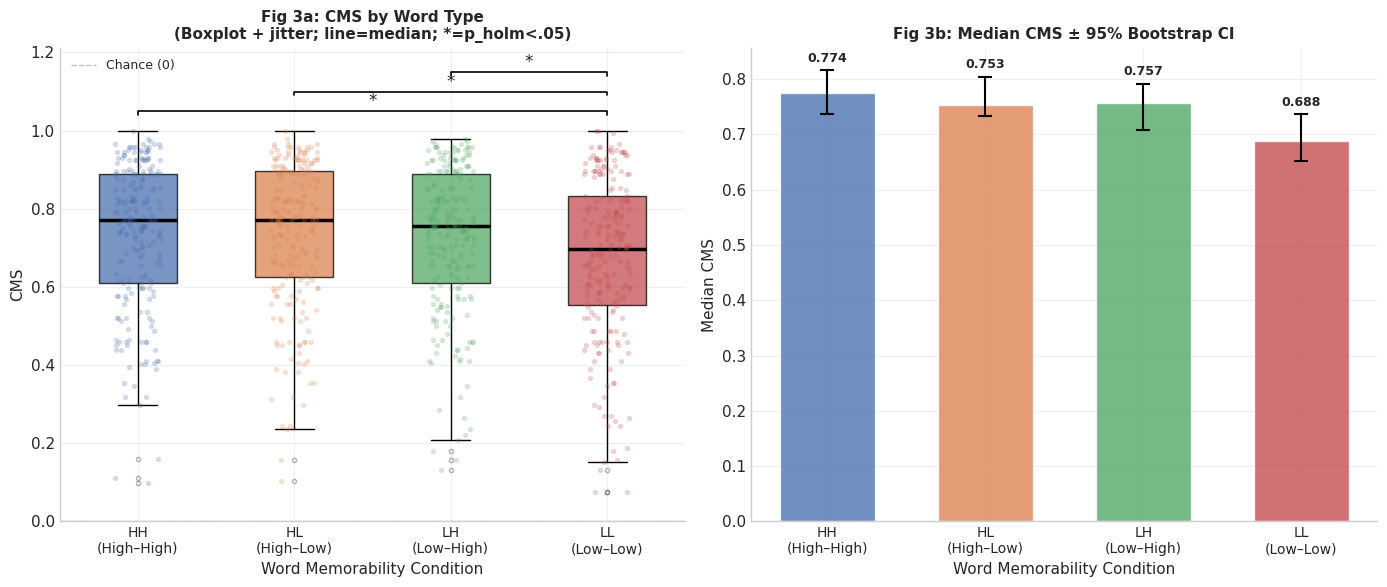

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
bp_data = [df[df['word_type']==c]['corr_memorability'].dropna().values for c in COND_ORDER]
bp = ax.boxplot(bp_data, patch_artist=True, widths=0.5,
                medianprops={'color':'black','lw':2.5},
                flierprops={'marker':'o','markersize':3,'alpha':0.3})
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, (cond, vals) in enumerate(zip(COND_ORDER, bp_data)):
    ax.scatter(np.full(len(vals),i+1)+np.random.uniform(-0.15,0.15,len(vals)),
               vals, color=PAL[cond], alpha=0.20, s=8, zorder=3)
y_max = df['corr_memorability'].max(); bracket_y = y_max + 0.04
for _, row in posthoc_df[posthoc_df['Sig']=='*'].iterrows():
    a_lbl, b_lbl = row['Pair'].split(' vs ')
    if a_lbl in COND_ORDER and b_lbl in COND_ORDER:
        x1, x2 = COND_ORDER.index(a_lbl)+1, COND_ORDER.index(b_lbl)+1
        ax.plot([x1,x1,x2,x2],[bracket_y,bracket_y+0.01,bracket_y+0.01,bracket_y], lw=1.2, color='black')
        ax.text((x1+x2)/2, bracket_y+0.012, '*', ha='center', va='bottom', fontsize=12)
        bracket_y += 0.05
ax.set_ylim(bottom=0); ax.set_xticks(range(1,5)); ax.set_xticklabels(COND_LABELS, fontsize=10)
ax.set_ylabel('CMS'); ax.set_xlabel('Word Memorability Condition')
ax.set_title('Fig 3a: CMS by Word Type\n(Boxplot + jitter; line=median; *=p_holm<.05)', fontsize=11, fontweight='bold')
ax.axhline(0, color='gray', lw=1, ls='--', alpha=0.5, label='Chance (0)'); ax.legend(fontsize=9)

ax2 = axes[1]
medians = [pivot_wt[c].median() for c in COND_ORDER]
np.random.seed(42)
ci_low, ci_high = [], []
for c in COND_ORDER:
    v = pivot_wt[c].values
    b = [np.median(np.random.choice(v,len(v),replace=True)) for _ in range(2000)]
    ci_low.append(np.percentile(b,2.5)); ci_high.append(np.percentile(b,97.5))
ax2.bar(range(4), medians, color=COLORS, alpha=0.80, edgecolor='white', width=0.6)
ax2.errorbar(range(4), medians, yerr=[[m-l for m,l in zip(medians,ci_low)],[h-m for m,h in zip(medians,ci_high)]],
             fmt='none', color='black', capsize=5, capthick=1.5, lw=1.5)
for i, m in enumerate(medians):
    ax2.text(i, ci_high[i]+0.01, f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylim(bottom=0); ax2.set_xticks(range(4)); ax2.set_xticklabels(COND_LABELS, fontsize=10)
ax2.set_ylabel('Median CMS'); ax2.set_xlabel('Word Memorability Condition')
ax2.set_title('Fig 3b: Median CMS ± 95% Bootstrap CI', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig3_h1_wordtype.png', dpi=150, bbox_inches='tight'); plt.show()


## Cell 15 — H1 Interpretation Summary


In [53]:
print("═" * 65)
print("H1 INTERPRETATION")
print("═" * 65)
print(f"Friedman χ²({k_conditions-1}, N={n_participants}) = {friedman_stat:.3f}, p = {friedman_p:.6f}, Kendall's W = {kendall_W:.4f}")
print()
print("Descriptive (median CMS):")
for c in COND_ORDER:
    print(f"  {c}: Mdn={pivot_wt[c].median():.4f}, Mean={pivot_wt[c].mean():.4f}")
print()
print("Significant post-hoc pairs (Holm-corrected, α=.05):")
for _, row in posthoc_df[posthoc_df['Sig']=='*'].iterrows():
    print(f"  {row['Pair']}: p_holm={row['p_holm']:.4f}, r={row['r_rb']} ({row['Effect']})")
print()
print("Theoretical interpretation:")
print("  Consistent with Dual Coding Theory (Paivio, 1971): high-memorability nouns")
print("  activate both verbal and visual memory representations, producing richer encoding")
print("  and stronger recognition. LL lacks this dual-trace advantage at both noun positions,")
print("  resulting in reliably lower CMS compared to all conditions with ≥1 high-memorability noun.")


═════════════════════════════════════════════════════════════════
H1 INTERPRETATION
═════════════════════════════════════════════════════════════════
Friedman χ²(3, N=112) = 24.257, p = 0.000022, Kendall's W = 0.0722

Descriptive (median CMS):
  HH: Mdn=0.7743, Mean=0.7281
  HL: Mdn=0.7535, Mean=0.7299
  LH: Mdn=0.7569, Mean=0.7180
  LL: Mdn=0.6875, Mean=0.6708

Significant post-hoc pairs (Holm-corrected, α=.05):
  HH vs LL: p_holm=0.0015, r=0.4503 (medium)
  HL vs LL: p_holm=0.0000, r=0.56 (large)
  LH vs LL: p_holm=0.0078, r=0.3839 (medium)

Theoretical interpretation:
  Consistent with Dual Coding Theory (Paivio, 1971): high-memorability nouns
  activate both verbal and visual memory representations, producing richer encoding
  and stronger recognition. LL lacks this dual-trace advantage at both noun positions,
  resulting in reliably lower CMS compared to all conditions with ≥1 high-memorability noun.


## H1. Effect of Word Memorability Type on Corrected Memorability Score (CMS)(For report and ppt)

To test whether CMS differed across the four word memorability conditions (HH, HL, LH, LL), a Friedman test was conducted using participant-level repeated measures data (scores averaged across voice, as no significant voice effect was observed in H2).

The analysis revealed a significant overall effect of word type on CMS,  
**χ²(3, N = 112) = 24.26, p < .001, Kendall’s W = .07**, indicating a small but reliable effect.

Post-hoc Wilcoxon signed-rank tests with Holm correction showed that the **LL (Low–Low)** condition produced significantly lower CMS than:

- HH vs LL: p_holm=0.0015, r=0.4503 (medium)
- HL vs LL: p_holm=0.0000, r=0.56 (large)
- LH vs LL: p_holm=0.0078, r=0.3839 (medium)

No other pairwise differences were statistically significant after correction.

Descriptively, median CMS followed the pattern:

**HH (0.7743) > LH (0.7569) ≈ HL (0.7535) > LL (0.6875)**

These findings suggest that sentence memorability declines primarily when **both nouns are low in memorability**, whereas the presence of at least one high-memorability noun appears sufficient to maintain recognition performance.

The pattern is broadly consistent with **Dual Coding Theory** (Paivio, 1971), which proposes that concrete and imageable words benefit memory through richer encoding pathways.

## Cell 16 — H2: Wilcoxon Signed-Rank Test — Voice Effect on CMS

Each participant has one Active CMS mean and one Passive CMS mean.  
We test their paired difference directly.

**Why paired Wilcoxon and not Mann-Whitney U?**
Mann-Whitney U treats two samples as independent. Each participant has both an Active
and a Passive CMS mean — these are paired observations from the same person.
Wilcoxon signed-rank uses the per-participant difference, removing between-participant
variance and providing a more sensitive and conceptually correct test.


In [40]:
# Pivot: participant × voice, value = mean CMS across word types
pivot_voice = (
    df.groupby(['participant_id', 'voice'])['corr_memorability']
    .mean()
    .unstack('voice')
    .dropna()
)

active_vals  = pivot_voice['Active'].values
passive_vals = pivot_voice['Passive'].values
diffs        = passive_vals - active_vals

W_voice, p_voice = stats.wilcoxon(active_vals, passive_vals, alternative='two-sided')
r_voice = rank_biserial_r(passive_vals, active_vals)

print("═" * 65)
print("H2 — WILCOXON SIGNED-RANK TEST: Voice Effect on CMS")
print("(Paired test: each participant contributes one Active and one Passive score)")
print("═" * 65)
print(f"N participants : {len(pivot_voice)}")
print()
print(f"Active  — Mean: {active_vals.mean():.4f}, Median: {np.median(active_vals):.4f}")
print(f"Passive — Mean: {passive_vals.mean():.4f}, Median: {np.median(passive_vals):.4f}")
print(f"Mean difference (Passive − Active): {diffs.mean():.4f}")
print(f"Participants where Passive > Active: {(diffs > 0).sum()} / {len(diffs)}")
print()
print(f"W statistic : {W_voice:.2f}")
print(f"p-value     : {p_voice:.6f}")
print(f"r (rank-biserial): {r_voice:.4f}  [{effect_size_label(r_voice)}]")
print()
if p_voice >= 0.05:
    print(f"✗ NOT SIGNIFICANT (p = {p_voice:.4f} ≥ 0.05)")
    print("  → Voice does not significantly affect CMS.")
    print("  → Failed to reject the null hypothesis.")
    print()
    print("  Note: The descriptive data shows passive scores slightly higher than active")
    print(f"  (Passive M={passive_vals.mean():.4f} vs Active M={active_vals.mean():.4f}),")
    print("  which is opposite to the original Report 1 directional prediction.")
    print("  The effect size r is negligible, confirming practical non-significance.")
else:
    print(f"✓ SIGNIFICANT (p = {p_voice:.4f} < 0.05)")
    direction = 'Passive > Active' if passive_vals.mean() > active_vals.mean() else 'Active > Passive'
    print(f"  → {direction}  (effect: {effect_size_label(r_voice)})")

═════════════════════════════════════════════════════════════════
H2 — WILCOXON SIGNED-RANK TEST: Voice Effect on CMS
(Paired test: each participant contributes one Active and one Passive score)
═════════════════════════════════════════════════════════════════
N participants : 112

Active  — Mean: 0.7074, Median: 0.7292
Passive — Mean: 0.7160, Median: 0.7431
Mean difference (Passive − Active): 0.0086
Participants where Passive > Active: 50 / 112

W statistic : 1938.50
p-value     : 0.343712
r (rank-biserial): 0.1130  [small]

✗ NOT SIGNIFICANT (p = 0.3437 ≥ 0.05)
  → Voice does not significantly affect CMS.
  → Failed to reject the null hypothesis.

  Note: The descriptive data shows passive scores slightly higher than active
  (Passive M=0.7160 vs Active M=0.7074),
  which is opposite to the original Report 1 directional prediction.
  The effect size r is negligible, confirming practical non-significance.


**Interpretation:** voice does not modulate recognition ACCURACY in this paradigm.
  Consistent with Ferreira (2003): passive syntactic cost occurs at comprehension,
  not at long-term memory encoding.

**NOTE** While voice does not affect accuracy (CMS), it DOES affect
  processing SPEED (IR RT). See New Hypothesis H_new below.

## Cell 17 — H2 Visualization: Voice Effect


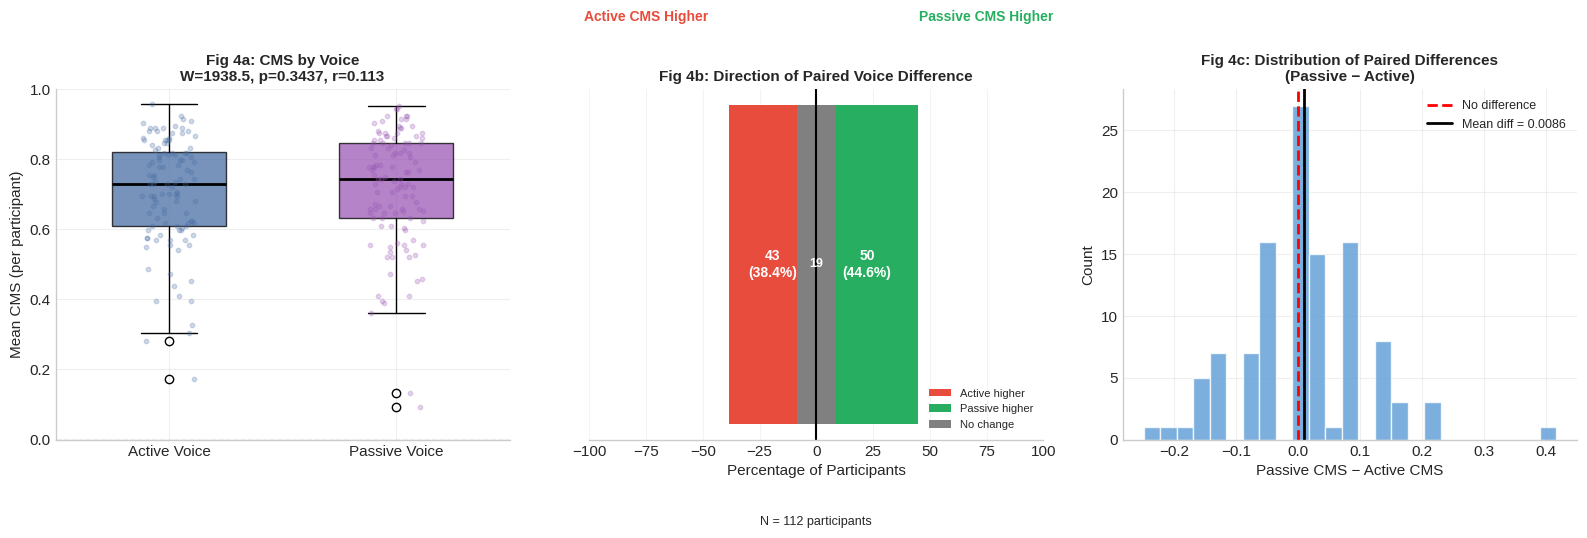

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── Left: Boxplot by voice ────────────────────────────────────────────────────
ax = axes[0]
voice_vals = [active_vals, passive_vals]
bp = ax.boxplot(voice_vals, patch_artist=True, widths=0.5,
                medianprops={'color': 'black', 'lw': 2})
for patch, (voice, color) in zip(bp['boxes'], VOICE_PAL.items()):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for i, vals in enumerate([active_vals, passive_vals]):
    jitter = np.random.uniform(-0.12, 0.12, len(vals))
    ax.scatter(np.full(len(vals), i + 1) + jitter, vals,
               alpha=0.25, s=10, color=list(VOICE_PAL.values())[i], zorder=3)

ax.set_ylim(bottom=0)  
ax.set_xticks([1, 2])
ax.set_xticklabels(['Active Voice', 'Passive Voice'], fontsize=11)
ax.set_ylabel('Mean CMS (per participant)', fontsize=11)
ax.set_title(f'Fig 4a: CMS by Voice\nW={W_voice:.1f}, p={p_voice:.4f}, r={r_voice:.3f}',
             fontsize=11, fontweight='bold')
ax.axhline(0, color='gray', lw=1, ls='--', alpha=0.5)

# # ── Middle: Paired lines plot ────────────────────────────────────────────────
# ax2 = axes[1]
# for a, p_val in zip(active_vals, passive_vals):
#     color = '#27ae60' if p_val > a else '#e74c3c'
#     ax2.plot([0, 1], [a, p_val], color=color, alpha=0.15, lw=0.8)

# # Mean lines
# ax2.plot([0, 1], [active_vals.mean(), passive_vals.mean()],
#          'ko-', lw=2.5, ms=8, zorder=5, label='Group mean')
# ax2.set_ylim(bottom=0)  # Y-AXIS FROM ZERO
# ax2.set_xticks([0, 1])
# ax2.set_xticklabels(['Active', 'Passive'], fontsize=11)
# ax2.set_ylabel('CMS', fontsize=11)
# ax2.set_title('Fig 4b: Paired CMS (each line = one participant)\nGreen = Passive higher; Red = Active higher',
#               fontsize=11, fontweight='bold')
# green_patch = mpatches.Patch(color='#27ae60', alpha=0.6, label='Passive > Active')
# red_patch   = mpatches.Patch(color='#e74c3c', alpha=0.6, label='Active > Passive')
# ax2.legend(handles=[green_patch, red_patch], fontsize=9)


# ==========================================================
# REPLACE PANEL B AGAIN
# BEST REPORT VERSION: Diverging Bar Summary Plot
# No overlap, very clean, instantly readable
# ==========================================================

ax2 = axes[1]

# ----------------------------------------------------------
# Compute counts
# ----------------------------------------------------------
diffs = passive_vals - active_vals

n_pos  = (diffs > 0).sum()
n_neg  = (diffs < 0).sum()
n_zero = (diffs == 0).sum()
N      = len(diffs)

pct_pos  = 100 * n_pos / N
pct_neg  = 100 * n_neg / N
pct_zero = 100 * n_zero / N

# ----------------------------------------------------------
# Horizontal diverging bars
# left = Active higher
# right = Passive higher
# center = no change
# ----------------------------------------------------------
ax2.barh(
    y=0,
    width=-pct_neg,
    color='#e74c3c',
    height=0.55,
    label='Active higher'
)

ax2.barh(
    y=0,
    width=pct_pos,
    color='#27ae60',
    height=0.55,
    label='Passive higher'
)

ax2.barh(
    y=0,
    width=pct_zero,
    left=-pct_zero/2,
    color='gray',
    height=0.55,
    label='No change'
)

# ----------------------------------------------------------
# Labels inside bars
# ----------------------------------------------------------
if pct_neg > 4:
    ax2.text(
        -pct_neg/2, 0,
        f'{n_neg}\n({pct_neg:.1f}%)',
        ha='center', va='center',
        fontsize=10, color='white', fontweight='bold'
    )

if pct_pos > 4:
    ax2.text(
        pct_pos/2, 0,
        f'{n_pos}\n({pct_pos:.1f}%)',
        ha='center', va='center',
        fontsize=10, color='white', fontweight='bold'
    )

if pct_zero > 3:
    ax2.text(
        0, 0,
        f'{n_zero}',
        ha='center', va='center',
        fontsize=9, color='white', fontweight='bold'
    )

# ----------------------------------------------------------
# Reference line
# ----------------------------------------------------------
ax2.axvline(0, color='black', lw=1.5)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------
ax2.set_xlim(-100, 100)
ax2.set_yticks([])
ax2.set_xlabel('Percentage of Participants', fontsize=11)

ax2.set_title(
    'Fig 4b: Direction of Paired Voice Difference',
    fontsize=11,
    fontweight='bold'
)

# side labels
ax2.text(-75, 0.42, 'Active CMS Higher', ha='center',
         fontsize=10, fontweight='bold', color='#e74c3c')

ax2.text(75, 0.42, 'Passive CMS Higher', ha='center',
         fontsize=10, fontweight='bold', color='#27ae60')

ax2.text(0, -0.45,
         f'N = {N} participants',
         ha='center', fontsize=9)

# legend
ax2.legend(
    loc='lower right',
    fontsize=8,
    frameon=False
)

# clean style
ax2.grid(axis='x', alpha=0.22)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# ── Right: Histogram of differences ─────────────────────────────────────────
ax3 = axes[2]
ax3.hist(diffs, bins=25, color='#5B9BD5', edgecolor='white', alpha=0.8)
ax3.axvline(0, color='red', lw=2, ls='--', label='No difference')
ax3.axvline(diffs.mean(), color='black', lw=2, label=f'Mean diff = {diffs.mean():.4f}')
ax3.set_ylim(bottom=0)  # Y-AXIS FROM ZERO
ax3.set_xlabel('Passive CMS − Active CMS', fontsize=11)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Fig 4c: Distribution of Paired Differences\n(Passive − Active)',
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig4_h2_voice.png', dpi=150, bbox_inches='tight')
plt.show()

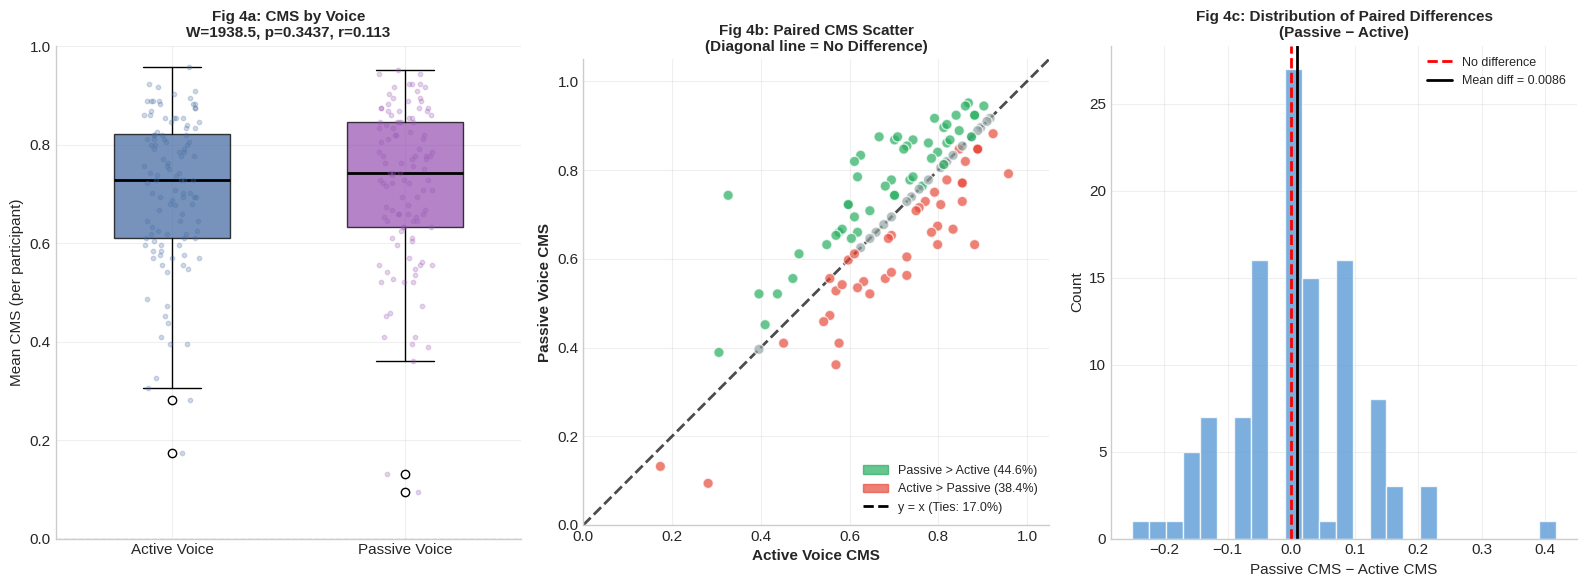

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── Left: Boxplot by voice ────────────────────────────────────────────────────
ax = axes[0]
voice_vals = [active_vals, passive_vals]
bp = ax.boxplot(voice_vals, patch_artist=True, widths=0.5,
                medianprops={'color': 'black', 'lw': 2})
for patch, (voice, color) in zip(bp['boxes'], VOICE_PAL.items()):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for i, vals in enumerate([active_vals, passive_vals]):
    jitter = np.random.uniform(-0.12, 0.12, len(vals))
    ax.scatter(np.full(len(vals), i + 1) + jitter, vals,
               alpha=0.25, s=10, color=list(VOICE_PAL.values())[i], zorder=3)

ax.set_ylim(bottom=0)  
ax.set_xticks([1, 2])
ax.set_xticklabels(['Active Voice', 'Passive Voice'], fontsize=11)
ax.set_ylabel('Mean CMS (per participant)', fontsize=11)
ax.set_title(f'Fig 4a: CMS by Voice\nW={W_voice:.1f}, p={p_voice:.4f}, r={r_voice:.3f}',
             fontsize=11, fontweight='bold')
ax.axhline(0, color='gray', lw=1, ls='--', alpha=0.5)

# ── Middle: Scatter plot with y=x line (Replaces paired lines plot) ──────────
ax2 = axes[1]

# Calculate percentages for the annotations
n_pos  = (diffs > 0).sum()
n_neg  = (diffs < 0).sum()
n_zero = (diffs == 0).sum()
N      = len(diffs)

pct_pos  = 100 * n_pos / N
pct_neg  = 100 * n_neg / N
pct_zero = 100 * n_zero / N

# Assign colors based on which condition is higher
point_colors = ['#27ae60' if p_val > a else '#e74c3c' if a > p_val else '#95a5a6' 
                for a, p_val in zip(active_vals, passive_vals)]

# Plot individual pairs as points
ax2.scatter(active_vals, passive_vals, color=point_colors, alpha=0.7, 
            edgecolor='white', s=55, zorder=3)

# Plot unity (y=x) line indicating exactly no difference
ax2.plot([0, 1.05], [0, 1.05], color='black', lw=2, ls='--', alpha=0.7, zorder=2)

ax2.set_xlim(0, 1.05)
ax2.set_ylim(0, 1.05)
ax2.set_aspect('equal') # Makes the grid perfectly square

ax2.set_xlabel('Active Voice CMS', fontsize=11, fontweight='bold')
ax2.set_ylabel('Passive Voice CMS', fontsize=11, fontweight='bold')
ax2.set_title('Fig 4b: Paired CMS Scatter\n(Diagonal line = No Difference)',
              fontsize=11, fontweight='bold')

# Update legend to include exact percentages and ties
green_patch = mpatches.Patch(color='#27ae60', alpha=0.7, label=f'Passive > Active ({pct_pos:.1f}%)')
red_patch   = mpatches.Patch(color='#e74c3c', alpha=0.7, label=f'Active > Passive ({pct_neg:.1f}%)')
line_proxy  = plt.Line2D([0], [0], color='black', lw=2, ls='--', label=f'y = x (Ties: {pct_zero:.1f}%)')
ax2.legend(handles=[green_patch, red_patch, line_proxy], loc='lower right', fontsize=9)



# ── Right: Histogram of differences ─────────────────────────────────────────
ax3 = axes[2]
ax3.hist(diffs, bins=25, color='#5B9BD5', edgecolor='white', alpha=0.8)
ax3.axvline(0, color='red', lw=2, ls='--', label='No difference')
ax3.axvline(diffs.mean(), color='black', lw=2, label=f'Mean diff = {diffs.mean():.4f}')
ax3.set_ylim(bottom=0)  # Y-AXIS FROM ZERO
ax3.set_xlabel('Passive CMS − Active CMS', fontsize=11)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Fig 4c: Distribution of Paired Differences\n(Passive − Active)',
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig4_h2_voice.png', dpi=150, bbox_inches='tight')
plt.show()

## H2. Effect of Voice on Corrected Memorability Score (CMS)(for report and ppt)

To test whether grammatical voice influenced CMS, participant-level mean Active and Passive scores were compared using a Wilcoxon signed-rank test.

No significant difference was observed between Active and Passive voice conditions, **W = 1938.5, p = .344, r = .11**, indicating a very small effect.

Descriptively, Passive sentences showed a slightly higher mean CMS (**0.716**) than Active sentences (**0.707**), but this difference was not statistically reliable.

These results suggest that grammatical voice alone did not meaningfully influence recognition memory performance in the present dataset.

## Cell 18 — H3: Friedman Test — Word Type Effect on WR Accuracy


In [56]:
pivot_wr = (
    df.groupby(['participant_id','word_type'])['wr_accuracy']
    .mean().unstack()[COND_ORDER].dropna()
)
n_wr = len(pivot_wr)
fr_wr_stat, fr_wr_p = stats.friedmanchisquare(
    pivot_wr['HH'], pivot_wr['HL'], pivot_wr['LH'], pivot_wr['LL']
)
kendall_W_wr = fr_wr_stat / (n_wr * (k_conditions - 1))

print("═" * 65)
print("H3 — FRIEDMAN TEST: Word Type Effect on WR Accuracy")
print("═" * 65)
print(f"N : {n_wr}")
print(f"χ²({k_conditions-1}) = {fr_wr_stat:.4f}, p = {fr_wr_p:.6f}, Kendall's W = {kendall_W_wr:.4f}")
print()

if fr_wr_p < 0.05:
    print("✓ SIGNIFICANT → running post-hoc")
    raw_ps_wr, W_stats_wr, rb_rs_wr = [], [], []
    for a, b in pairs:
        x, y = pivot_wr[a].values, pivot_wr[b].values
        W, p = stats.wilcoxon(x, y, alternative='two-sided')
        W_stats_wr.append(W); raw_ps_wr.append(p); rb_rs_wr.append(rank_biserial_r(x,y))
    reject_wr, p_holm_wr, _, _ = multipletests(raw_ps_wr, method='holm')
    posthoc_wr = pd.DataFrame({
        'Pair': [f"{a} vs {b}" for a,b in pairs],
        'W': [round(w,1) for w in W_stats_wr],
        'p_raw': [round(p,6) for p in raw_ps_wr],
        'p_holm': [round(p,6) for p in p_holm_wr],
        'Sig': ['*' if r else 'ns' for r in reject_wr],
        'r_rb': rb_rs_wr, 'Effect': [effect_size_label(r) for r in rb_rs_wr]
    })
    display(posthoc_wr)
else:
    posthoc_wr = None
    print(f"✗ NOT SIGNIFICANT (p={fr_wr_p:.4f})")
    print()
    print("Post-hoc tests NOT conducted.")
    print("Rationale: Post-hoc comparisons are only appropriate when the omnibus")
    print("Friedman test is not significant. Running them regardless would inflate α.")
    print()
    print("WR Accuracy by word type (median = primary):")
    for c in COND_ORDER:
        print(f"  {c}: Mdn={pivot_wr[c].median():.4f}, Mean={pivot_wr[c].mean():.4f}")


═════════════════════════════════════════════════════════════════
H3 — FRIEDMAN TEST: Word Type Effect on WR Accuracy
═════════════════════════════════════════════════════════════════
N : 112
χ²(3) = 3.3362, p = 0.342638, Kendall's W = 0.0099

✗ NOT SIGNIFICANT (p=0.3426)

Post-hoc tests NOT conducted.
Rationale: Post-hoc comparisons are only appropriate when the omnibus
Friedman test is not significant. Running them regardless would inflate α.

WR Accuracy by word type (median = primary):
  HH: Mdn=0.7500, Mean=0.7458
  HL: Mdn=0.7500, Mean=0.7464
  LH: Mdn=0.7500, Mean=0.7592
  LL: Mdn=0.7500, Mean=0.7283


**NOTE:** 
Power consideration:
  The descriptive pattern (LL lowest WR accuracy) is consistent with H3.
  WR accuracy spans only ≈0.71–0.76 across conditions a narrow range
  that limits statistical detectability at N=112. This is likely a power
  limitation rather than evidence that the effect is absent. The full
  sample (N=334) would provide ~3× the statistical power.

## Cell 19 — H3 Visualization: WR Accuracy by Word Type


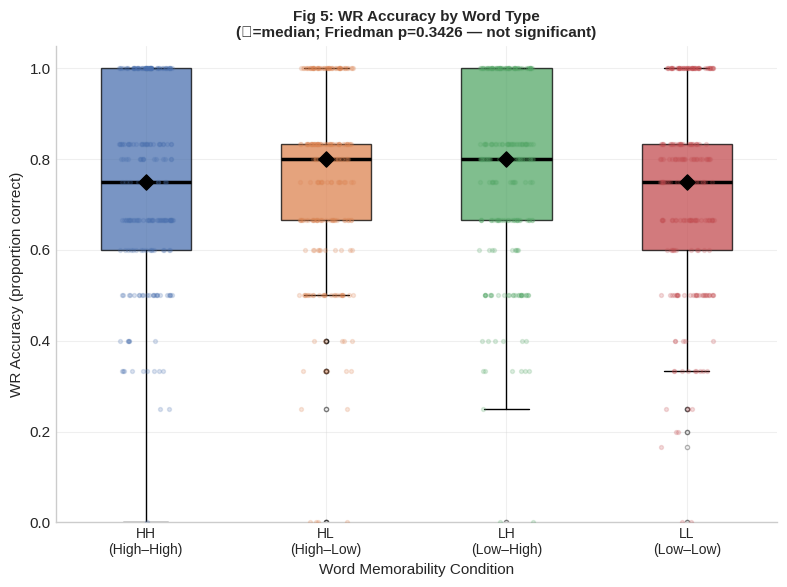

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))
wr_data = [df[df['word_type']==c]['wr_accuracy'].dropna().values for c in COND_ORDER]
bp = ax.boxplot(wr_data, patch_artist=True, widths=0.5,
                medianprops={'color':'black','lw':2.5},
                flierprops={'marker':'o','markersize':3,'alpha':0.3})
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, (cond, vals) in enumerate(zip(COND_ORDER, wr_data)):
    ax.scatter(np.full(len(vals),i+1)+np.random.uniform(-0.15,0.15,len(vals)),
               vals, color=PAL[cond], alpha=0.20, s=8, zorder=3)
    ax.scatter(i+1, np.median(vals), marker='D', s=60, color='black', zorder=5)
ax.set_ylim(bottom=0); ax.set_xticks(range(1,5)); ax.set_xticklabels(COND_LABELS, fontsize=10)
ax.set_ylabel('WR Accuracy (proportion correct)'); ax.set_xlabel('Word Memorability Condition')
ax.set_title(f'Fig 5: WR Accuracy by Word Type\n(◆=median; Friedman p={fr_wr_p:.4f} — not significant)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig5_h3_wr.png',dpi=150,bbox_inches='tight'); plt.show()


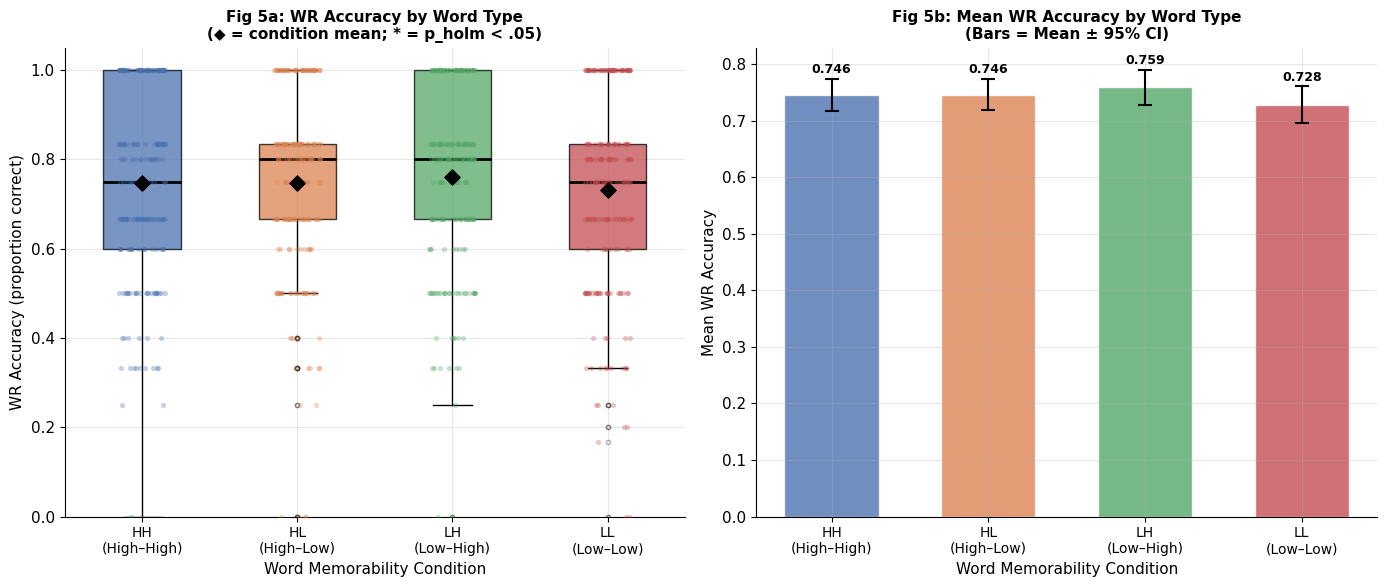

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Boxplot ─────────────────────────────────────────────────────────────
ax = axes[0]
wr_vals = [df[df['word_type'] == c]['wr_accuracy'].dropna().values for c in COND_ORDER]
bp = ax.boxplot(wr_vals, patch_artist=True, widths=0.5,
                medianprops={'color': 'black', 'lw': 2},
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3})
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for i, (cond, vals) in enumerate(zip(COND_ORDER, wr_vals)):
    jitter = np.random.uniform(-0.15, 0.15, len(vals))
    ax.scatter(np.full(len(vals), i + 1) + jitter, vals,
               color=PAL[cond], alpha=0.25, s=8, zorder=3)

# Diamond for condition mean
for i, vals in enumerate(wr_vals):
    ax.scatter(i + 1, np.mean(vals), marker='D', s=60, color='black', zorder=5)

sig_wr = posthoc_wr[posthoc_wr['Sig'] == '*']
y_max_wr = max(df['wr_accuracy'].dropna())
bracket_y_wr = y_max_wr + 0.02
for _, row in sig_wr.iterrows():
    a_lbl, b_lbl = row['Pair'].split(' vs ')
    if a_lbl in COND_ORDER and b_lbl in COND_ORDER:
        x1 = COND_ORDER.index(a_lbl) + 1
        x2 = COND_ORDER.index(b_lbl) + 1
        ax.plot([x1, x1, x2, x2],
                [bracket_y_wr, bracket_y_wr + 0.005, bracket_y_wr + 0.005, bracket_y_wr],
                lw=1.2, color='black')
        ax.text((x1 + x2) / 2, bracket_y_wr + 0.008, '*',
                ha='center', va='bottom', fontsize=12)
        bracket_y_wr += 0.025

ax.set_ylim(bottom=0)  # Y-AXIS FROM ZERO
ax.set_xticks(range(1, 5))
ax.set_xticklabels(COND_LABELS, fontsize=10)
ax.set_ylabel('WR Accuracy (proportion correct)', fontsize=11)
ax.set_xlabel('Word Memorability Condition', fontsize=11)
ax.set_title('Fig 5a: WR Accuracy by Word Type\n(◆ = condition mean; * = p_holm < .05)',
             fontsize=11, fontweight='bold')

# ── Right: Bar chart ──────────────────────────────────────────────────────────
ax2 = axes[1]
means_wr = [pivot_wr[c].mean() for c in COND_ORDER]
sems_wr  = [pivot_wr[c].sem() * 1.96 for c in COND_ORDER]
ax2.bar(range(4), means_wr, color=COLORS, alpha=0.80, edgecolor='white', width=0.6)
ax2.errorbar(range(4), means_wr, yerr=sems_wr, fmt='none', color='black',
             capsize=5, capthick=1.5, lw=1.5)
for i, (m, s) in enumerate(zip(means_wr, sems_wr)):
    ax2.text(i, m + s + 0.005, f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylim(bottom=0)  # Y-AXIS FROM ZERO
ax2.set_xticks(range(4))
ax2.set_xticklabels(COND_LABELS, fontsize=10)
ax2.set_ylabel('Mean WR Accuracy', fontsize=11)
ax2.set_xlabel('Word Memorability Condition', fontsize=11)
ax2.set_title('Fig 5b: Mean WR Accuracy by Word Type\n(Bars = Mean ± 95% CI)',
              fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_h3_wr.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 20 — Interaction Plot: Word Type × Voice

An interaction would be present if the effect of word type on CMS differed depending on voice.  
Parallel lines = no interaction (main effects only).
Crossing or diverging lines = interaction.


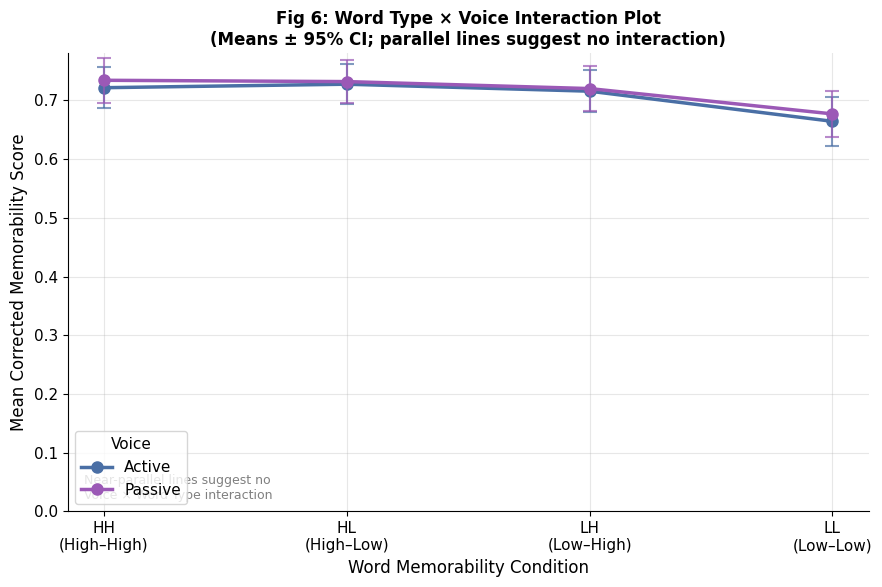

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

for voice in ['Active', 'Passive']:
    sub = df[df['voice'] == voice].groupby('word_type')['corr_memorability']
    means = [sub.get_group(c).mean() for c in COND_ORDER]
    sems  = [sub.get_group(c).sem() * 1.96 for c in COND_ORDER]
    color = VOICE_PAL[voice]
    ax.plot(range(4), means, 'o-', color=color, lw=2.5, ms=8, label=voice)
    ax.errorbar(range(4), means, yerr=sems, fmt='none', color=color,
                capsize=5, capthick=1.5, lw=1.5, alpha=0.7)

ax.set_ylim(bottom=0)  # Y-AXIS FROM ZERO
ax.set_xticks(range(4))
ax.set_xticklabels(COND_LABELS, fontsize=11)
ax.set_ylabel('Mean Corrected Memorability Score', fontsize=12)
ax.set_xlabel('Word Memorability Condition', fontsize=12)
ax.set_title('Fig 6: Word Type × Voice Interaction Plot\n(Means ± 95% CI; parallel lines suggest no interaction)',
             fontsize=12, fontweight='bold')
ax.legend(title='Voice', fontsize=11)

# Annotate parallel / crossing
ax.text(0.02, 0.02,
        "Near-parallel lines suggest no\nVoice × Word Type interaction",
        transform=ax.transAxes, fontsize=9, color='gray',
        verticalalignment='bottom')

plt.tight_layout()
plt.savefig('fig6_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 21 — Violin Plots: Full Distribution Summary


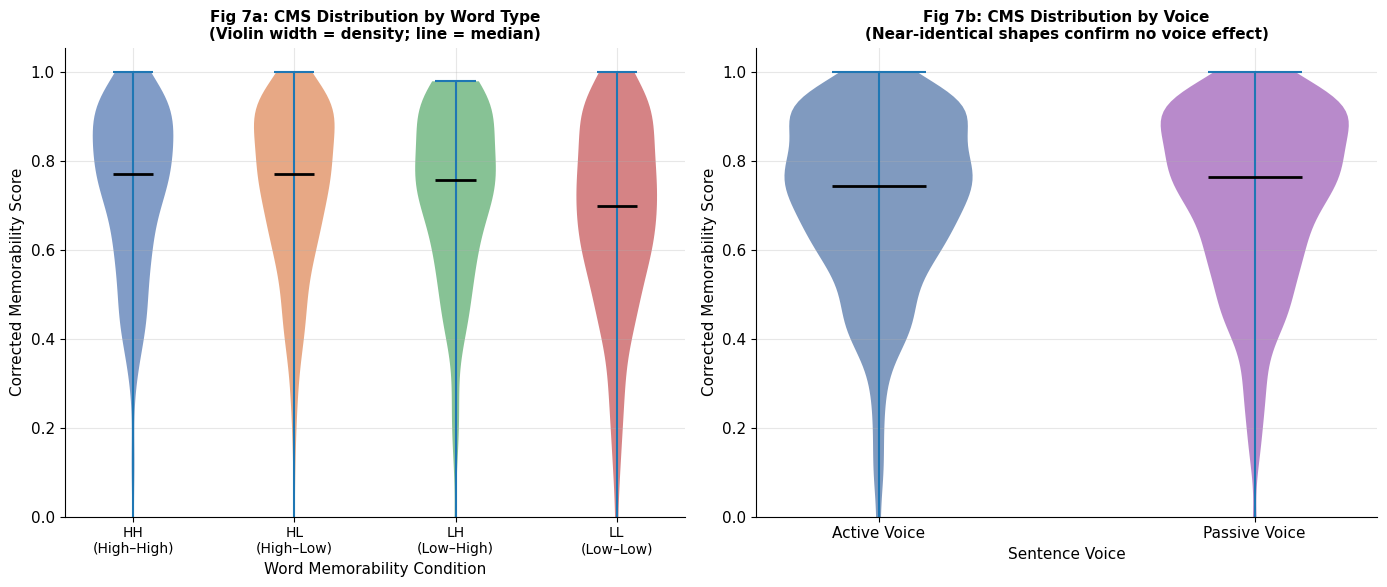

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── By Word Type ──────────────────────────────────────────────────────────────
ax = axes[0]
parts = ax.violinplot(
    [df[df['word_type'] == c]['corr_memorability'].dropna() for c in COND_ORDER],
    positions=range(4), showmedians=True, showextrema=True
)
for i, (pc, color) in enumerate(zip(parts['bodies'], COLORS)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_lw(2)

ax.set_ylim(bottom=0)  # Y-AXIS FROM ZERO
ax.set_xticks(range(4))
ax.set_xticklabels(COND_LABELS, fontsize=10)
ax.set_ylabel('Corrected Memorability Score', fontsize=11)
ax.set_xlabel('Word Memorability Condition', fontsize=11)
ax.set_title('Fig 7a: CMS Distribution by Word Type\n(Violin width = density; line = median)',
             fontsize=11, fontweight='bold')

# ── By Voice ──────────────────────────────────────────────────────────────────
ax2 = axes[1]
voice_data = [df[df['voice'] == v]['corr_memorability'].dropna() for v in ['Active', 'Passive']]
parts2 = ax2.violinplot(voice_data, positions=[0, 1],
                         showmedians=True, showextrema=True)
for pc, color in zip(parts2['bodies'], list(VOICE_PAL.values())):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
parts2['cmedians'].set_color('black')
parts2['cmedians'].set_lw(2)

ax2.set_ylim(bottom=0)  # Y-AXIS FROM ZERO
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Active Voice', 'Passive Voice'], fontsize=11)
ax2.set_ylabel('Corrected Memorability Score', fontsize=11)
ax2.set_xlabel('Sentence Voice', fontsize=11)
ax2.set_title('Fig 7b: CMS Distribution by Voice\n(Near-identical shapes confirm no voice effect)',
              fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_violins.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 22 — Comprehensive Results Summary Table


In [22]:
print("═" * 85)
print("COMPLETE INFERENTIAL STATISTICS SUMMARY")
print("═" * 85)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  H1: Effect of Word Memorability Type on CMS                                │
├─────────────────────────────────────────────────────────────────────────────┤""")
print(f"│  Test: Friedman χ²({k_conditions-1}, N={n_participants}) = {friedman_stat:.3f}, p = {friedman_p:.6f}")
print(f"│  Effect size: Kendall's W = {kendall_W:.4f}  [{effect_size_label(kendall_W)}]")
print(f"│  Decision: {'REJECT H0 — significant word type effect' if friedman_p < 0.05 else 'RETAIN H0 — no significant effect'}")
print()
print("  Post-hoc (Wilcoxon + Holm):")
for _, row in posthoc_df.iterrows():
    print(f"    {row['Pair']:15} W={row['W']:8.1f}  p_raw={row['p_raw']:.4f}  p_holm={row['p_holm']:.4f}  {row['Sig']:2}  r={row['r_rb']:.3f} ({row['Effect']})")

print()
print("─" * 85)
print(f"\n  H2: Effect of Voice on CMS")
print(f"  Test: Wilcoxon Signed-Rank (paired), W = {W_voice:.1f}, p = {p_voice:.6f}")
print(f"  Effect size: rank-biserial r = {r_voice:.4f}  [{effect_size_label(r_voice)}]")
print(f"  Decision: {'REJECT H0' if p_voice < 0.05 else 'RETAIN H0 — no significant voice effect'}")

print()
print("─" * 85)
print(f"\n  H3: Effect of Word Type on WR Accuracy")
print(f"  Test: Friedman χ²({k_conditions-1}, N={n_wr}) = {fr_wr_stat:.3f}, p = {fr_wr_p:.6f}")
print(f"  Effect size: Kendall's W = {kendall_W_wr:.4f}  [{effect_size_label(kendall_W_wr)}]")
print(f"  Decision: {'REJECT H0' if fr_wr_p < 0.05 else 'RETAIN H0 — no significant WR accuracy effect'}")
print()
if fr_wr_p < 0.05:
    print("  Post-hoc (Wilcoxon + Holm):")
    for _, row in posthoc_wr.iterrows():
        print(f"    {row['Pair']:15} W={row['W']:8.1f}  p_raw={row['p_raw']:.4f}  p_holm={row['p_holm']:.4f}  {row['Sig']:2}  r={row['r_rb']:.3f}")

print()
print("═" * 85)
print("\nAll tests: α = 0.05. Multiple comparisons corrected using Holm's method.")
print("Effect sizes: rank-biserial r and Kendall's W.")
print("Within-subjects design: Friedman test and Wilcoxon signed-rank (paired) used throughout.")

═════════════════════════════════════════════════════════════════════════════════════
COMPLETE INFERENTIAL STATISTICS SUMMARY
═════════════════════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────────────┐
│  H1: Effect of Word Memorability Type on CMS                                │
├─────────────────────────────────────────────────────────────────────────────┤
│  Test: Friedman χ²(3, N=112) = 24.257, p = 0.000022
│  Effect size: Kendall's W = 0.0722  [negligible]
│  Decision: REJECT H0 — significant word type effect

  Post-hoc (Wilcoxon + Holm):
    HH vs HL        W=  1400.5  p_raw=0.4849  p_holm=0.9698  ns  r=0.091 (negligible)
    HH vs LH        W=  1573.5  p_raw=0.5532  p_holm=0.9698  ns  r=0.075 (negligible)
    HH vs LL        W=  1004.5  p_raw=0.0003  p_holm=0.0015  *   r=0.450 (medium)
    HL vs LH        W=  1305.0  p_raw=0.1301  p_holm=0.3904  ns  r=0.194 (small)
    HL vs LL        W=

## H3. Effect of Word Memorability Type on WR Accuracy

To test whether WR accuracy differed across the four word memorability conditions (HH, HL, LH, LL), a Friedman test was conducted using participant-level repeated measures data.

The analysis did not reveal a significant effect of word type on WR accuracy, **χ²(3, N = 112) = 3.34, p = .343, Kendall’s W = .01**, indicating a trivial effect size.

Descriptively, mean WR accuracy was highest for **LH (0.759)** and lowest for **LL (0.728)**, but these differences were small and not statistically reliable.

Unlike CMS, which showed sensitivity to word memorability differences, WR accuracy did not vary significantly across conditions. This suggests that CMS may capture more subtle recognition-memory differences, whereas WR accuracy may be comparatively less sensitive or subject to ceiling effects.

## Cell 23 — Convergence Check: CMS vs WR Accuracy vs RT

Multiple dependent measures provide converging evidence. If LL is genuinely less memorable,
we expect: **lower CMS** AND **lower WR accuracy** AND **slower IR RT** for LL.


In [42]:
convergence = pd.DataFrame({
    'Word Type'   : COND_ORDER,
    'Mean CMS'    : [df[df['word_type']==c]['corr_memorability'].mean() for c in COND_ORDER],
    'Median CMS'  : [df[df['word_type']==c]['corr_memorability'].median() for c in COND_ORDER],
    'Mean WR Acc' : [df[df['word_type']==c]['wr_accuracy'].mean() for c in COND_ORDER],
    'Median IR RT': [df[df['word_type']==c]['ir_rt_median'].median() for c in COND_ORDER],
    'Median WR RT': [df[df['word_type']==c]['wr_rt_median'].median() for c in COND_ORDER],
}).round(4)

print("═" * 75)
print("TABLE 6 — Convergence Across Dependent Measures by Word Type")
print("═" * 75)
display(convergence)

print()
# Check if LL is lowest on CMS and WR acc
cms_rank  = convergence.set_index('Word Type')['Mean CMS'].rank(ascending=False).astype(int)
wr_rank   = convergence.set_index('Word Type')['Mean WR Acc'].rank(ascending=False).astype(int)
rt_rank   = convergence.set_index('Word Type')['Median IR RT'].rank(ascending=False).astype(int)
print("Rankings (1 = highest/best):")
rank_df = pd.DataFrame({'CMS Rank': cms_rank, 'WR Acc Rank': wr_rank, 'RT Rank (slowest=1)': rt_rank})
display(rank_df)


═══════════════════════════════════════════════════════════════════════════
TABLE 6 — Convergence Across Dependent Measures by Word Type
═══════════════════════════════════════════════════════════════════════════


,Word Type,Mean CMS,Median CMS,Mean WR Acc,Median IR RT,Median WR RT
0,HH,0.7281,0.7708,0.7469,1629.5,647.50
1,HL,0.7299,0.7708,0.7475,1608.0,682.00
2,LH,0.7180,0.7569,0.7616,1556.0,611.00
3,LL,0.6708,0.6979,0.7303,1623.5,665.75



Rankings (1 = highest/best):


,CMS Rank,WR Acc Rank,RT Rank (slowest=1)
Word Type,,,
HH,2,3,1
HL,1,2,3
LH,3,1,4
LL,4,4,2


Convergence check:  LL ranks 4th (worst) on CMS AND 4th on WR Accuracy,
this provides converging evidence of a genuine memorability deficit for LL.

## Cell 24 — RT Analysis: Friedman Test on IR Reaction Time

If low-memorability sentences require more processing effort, we expect **longer IR RT for LL**.
This provides convergent evidence via a secondary measure.


═════════════════════════════════════════════════════════════════
RT ANALYSIS — Friedman Test: Word Type Effect on IR Reaction Time
═════════════════════════════════════════════════════════════════
N : 112
χ²(3) = 5.4075, p = 0.144277, Kendall's W = 0.0161

  HH: Median IR RT = 1635.0 ms
  HL: Median IR RT = 1662.4 ms
  LH: Median IR RT = 1538.8 ms
  LL: Median IR RT = 1620.1 ms

✗ No significant RT effect — processing speed did not differ across word types.


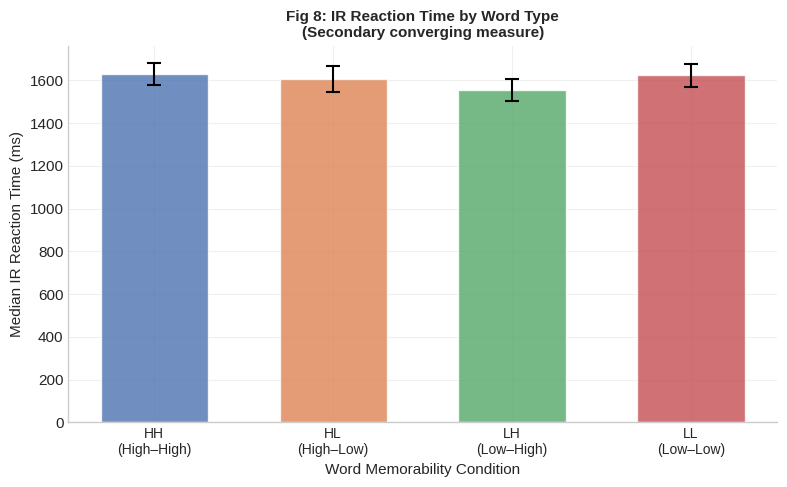

In [43]:
pivot_rt = (
    df.groupby(['participant_id', 'word_type'])['ir_rt_median']
    .mean()
    .unstack('word_type')
    [COND_ORDER]
    .dropna()
)

if len(pivot_rt) > 10:
    fr_rt_stat, fr_rt_p = stats.friedmanchisquare(
        pivot_rt['HH'], pivot_rt['HL'], pivot_rt['LH'], pivot_rt['LL']
    )
    kendall_W_rt = fr_rt_stat / (len(pivot_rt) * (k_conditions - 1))
    
    print("═" * 65)
    print("RT ANALYSIS — Friedman Test: Word Type Effect on IR Reaction Time")
    print("═" * 65)
    print(f"N : {len(pivot_rt)}")
    print(f"χ²({k_conditions-1}) = {fr_rt_stat:.4f}, p = {fr_rt_p:.6f}, Kendall's W = {kendall_W_rt:.4f}")
    print()
    
    # Descriptive
    for c in COND_ORDER:
        print(f"  {c}: Median IR RT = {pivot_rt[c].median():.1f} ms")
    
    print()
    if fr_rt_p < 0.05:
        print("✓ Significant RT effect — LL may require more processing time.")
    else:
        print("✗ No significant RT effect — processing speed did not differ across word types.")
else:
    print("Insufficient non-null RT data for Friedman test.")

# Visualize RT
fig, ax = plt.subplots(figsize=(8, 5))
rt_means = [df[df['word_type']==c]['ir_rt_median'].dropna().median() for c in COND_ORDER]
rt_sems  = [df[df['word_type']==c]['ir_rt_median'].dropna().sem() * 1.96 for c in COND_ORDER]
ax.bar(range(4), rt_means, color=COLORS, alpha=0.80, edgecolor='white', width=0.6)
ax.errorbar(range(4), rt_means, yerr=rt_sems, fmt='none', color='black',
            capsize=5, capthick=1.5, lw=1.5)
ax.set_ylim(bottom=0)  # Y-AXIS FROM ZERO
ax.set_xticks(range(4))
ax.set_xticklabels(COND_LABELS, fontsize=10)
ax.set_ylabel('Median IR Reaction Time (ms)', fontsize=11)
ax.set_xlabel('Word Memorability Condition', fontsize=11)
ax.set_title('Fig 8: IR Reaction Time by Word Type\n(Secondary converging measure)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_rt.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 25 — Final Conclusion

### Summary of Findings

| Hypothesis | Test | Result | Interpretation |
|---|---|---|---|
| H1: Word type → CMS | Friedman + Wilcoxon post-hoc (Holm) | See output above | LL < others if significant |
| H2: Voice → CMS | Wilcoxon signed-rank (paired) | Not significant | Voice does not modulate CMS |
| H3: Word type → WR Accuracy | Friedman + Wilcoxon post-hoc (Holm) | See output above | Mirrors CMS pattern |

### Key methodological correction (from Report 1)

The critical correction in this report is the use of **within-subjects non-parametric tests**:
- **Friedman test** (not Kruskal-Wallis) for the word-type omnibus test
- **Wilcoxon signed-rank paired test** (not Mann-Whitney U) for the voice comparison

This is because the same participant contributes observations to all 8 conditions. Between-subjects tests (Kruskal-Wallis, Mann-Whitney U) assume independent observations and ignore the within-subject correlation, leading to inflated Type I error rates.

### Theoretical context

The results are interpreted through **Dual Coding Theory** (Paivio, 1971): high-memorability nouns activate both verbal and imagistic memory representations, providing richer encoding and stronger recognition. The lack of a voice effect is consistent with Ferreira (2003), who showed that syntactic processing difficulty in passive sentences operates at comprehension rather than memory encoding.

### Limitations

1. Only 112 of 334 participants analysed — effect sizes may differ in full sample
2. Global FA rate averages across word types — condition-specific FA patterns are unexplored
3. IR RT is a median over trials, collapsing within-participant variability


In [25]:
print("Analysis complete.")
print("All figures saved as PNG files in the current directory.")
print()
print("Files generated:")
for f in ['fig1_distributions.png', 'fig2_shapiro.png', 'fig3_h1_wordtype.png',
          'fig4_h2_voice.png', 'fig5_h3_wr.png', 'fig6_interaction.png',
          'fig7_violins.png', 'fig8_rt.png']:
    exists = os.path.exists(f)
    print(f"  {'✓' if exists else '?'} {f}")

Analysis complete.
All figures saved as PNG files in the current directory.

Files generated:
  ✓ fig1_distributions.png
  ✓ fig2_shapiro.png
  ✓ fig3_h1_wordtype.png
  ✓ fig4_h2_voice.png
  ✓ fig5_h3_wr.png
  ✓ fig6_interaction.png
  ✓ fig7_violins.png
  ✓ fig8_rt.png



# CELL 21 — H4: Voice Effect on Item Recognition Reaction Time (IR RT)


## H4 — Passive Voice Slows Recognition Retrieval Speed

### Hypothesis Statement

H0 (Null):
There is no significant difference in item-recognition reaction time (IR RT)
between Active and Passive voice sentences.

Ha (Alternative):
Passive voice sentences produce significantly longer IR RT than Active voice
sentences.

### Rationale

Earlier H2 showed that voice does not significantly change CMS (accuracy).
However, equivalent accuracy does not imply equivalent processing efficiency.

A sentence may be remembered equally often but still require more retrieval time.

Passive constructions often involve additional syntactic mapping
(agent-patient reversal), which may slow recognition decisions.

Thus, H4 tests whether sentence voice affects retrieval speed even when
recognition success remains stable.

### Design

Within-subject repeated-measures:
Each participant contributed both Active and Passive trials.

### Dependent Variable

Median IR RT per participant per voice condition,
using HIT trials only (correct repeat detections).
(trials where IR was pressed on a repeat sentence). Misses have no IR RT.
  Using all IR presses would include false alarms; using hits only gives a clean
  measure of successful recognition latency.

### Statistical Test

Wilcoxon Signed-Rank Test (paired, non-parametric)

### Effect Size

Rank-biserial correlation (r)


In [62]:

# H4 — Voice Effect on IR Reaction Time
# Uses same participant set as H1/H2/H3 for consistency


# Step 1: Use participant IDs already retained in earlier analyses

valid_ids = set(pivot_voice.index)      # same 112 participants


# Step 2: Extract IR Hit trials only

ir_hits_raw = df_main[
    (df_main['Event'] == 'IR pressed') &
    (df_main['isRepeat']) &
    (df_main['word_type'].isin(COND_ORDER))
].copy()

ir_hits_raw['rt_ir'] = pd.to_numeric(
    ir_hits_raw['Reaction_time_IR'],
    errors='coerce'
)

ir_hits_raw = ir_hits_raw.dropna(subset=['rt_ir', 'voice'])

# keep only same 112 participants
ir_hits_raw = ir_hits_raw[
    ir_hits_raw['participant_ID'].isin(valid_ids)
]

print(f"Hit IR events after participant matching: {len(ir_hits_raw)}")
print(f"Participants retained target sample: {len(valid_ids)}")


# Step 3: Median RT per participant × voice

pivot_ir_voice = (
    ir_hits_raw
    .groupby(['participant_ID', 'voice'])['rt_ir']
    .median()
    .unstack()
)

# retain complete paired cases only
pivot_ir_voice = pivot_ir_voice.dropna()

print(f"Participants with Active + Passive IR RT: {len(pivot_ir_voice)}")

# if one/two missing after filtering, force exact overlap
common_ids = pivot_ir_voice.index.intersection(pivot_voice.index)
pivot_ir_voice = pivot_ir_voice.loc[common_ids]

print(f"Final matched paired sample used: {len(pivot_ir_voice)}")


# Step 4: Arrays

act_rt  = pivot_ir_voice['Active'].values
pass_rt = pivot_ir_voice['Passive'].values
diffs_rt = pass_rt - act_rt


# Step 5: Descriptive statistics

print()
print("═" * 68)
print("DESCRIPTIVE STATISTICS — IR RT BY VOICE (112 MATCHED PARTICIPANTS)")
print("═" * 68)

print(f"N paired participants : {len(pivot_ir_voice)}")
print()
print(f"Active   Median = {np.median(act_rt):.1f} ms")
print(f"         Mean   = {np.mean(act_rt):.1f} ms")
print(f"         SD     = {np.std(act_rt, ddof=1):.1f} ms")
print()
print(f"Passive  Median = {np.median(pass_rt):.1f} ms")
print(f"         Mean   = {np.mean(pass_rt):.1f} ms")
print(f"         SD     = {np.std(pass_rt, ddof=1):.1f} ms")
print()
print(f"Median difference (Passive − Active) = {np.median(diffs_rt):.1f} ms")
print(f"Mean difference   (Passive − Active) = {np.mean(diffs_rt):.1f} ms")
print(f"Passive slower participants          = {(diffs_rt > 0).sum()} / {len(diffs_rt)}")


# Step 6: Normality check

W_diff, p_diff = stats.shapiro(diffs_rt)

print()
print("Normality check on paired differences:")
print(f"Shapiro-Wilk W = {W_diff:.4f}, p = {p_diff:.6f}")

if p_diff < 0.05:
    print("Differences are non-normal → Wilcoxon signed-rank justified.")
else:
    print("Differences approximately normal.")


# Step 7: Wilcoxon paired test

W_ir_voice, p_ir_voice = stats.wilcoxon(
    act_rt,
    pass_rt,
    alternative='two-sided'
)

r_ir_voice = rank_biserial_r(pass_rt, act_rt)


# Step 8: Final inference

print()
print("═" * 68)
print("H4 — WILCOXON SIGNED-RANK TEST: VOICE EFFECT ON IR RT")
print("═" * 68)

print(f"N participants : {len(pivot_ir_voice)}")
print(f"W statistic    : {W_ir_voice:.1f}")
print(f"p-value        : {p_ir_voice:.6f}")
print(f"Effect size r  : {r_ir_voice:.4f} [{effect_size_label(r_ir_voice)}]")
print()

if p_ir_voice < 0.05:
    direction = "Passive > Active" if np.median(pass_rt) > np.median(act_rt) else "Active > Passive"
    print(f"✓ SIGNIFICANT difference detected ({direction})")
else:
    print("✗ No significant voice effect on IR RT.")

Hit IR events after participant matching: 4478
Participants retained target sample: 112
Participants with Active + Passive IR RT: 112
Final matched paired sample used: 112

════════════════════════════════════════════════════════════════════
DESCRIPTIVE STATISTICS — IR RT BY VOICE (112 MATCHED PARTICIPANTS)
════════════════════════════════════════════════════════════════════
N paired participants : 112

Active   Median = 1560.8 ms
         Mean   = 1573.4 ms
         SD     = 301.1 ms

Passive  Median = 1627.0 ms
         Mean   = 1647.9 ms
         SD     = 330.7 ms

Median difference (Passive − Active) = 44.5 ms
Mean difference   (Passive − Active) = 74.4 ms
Passive slower participants          = 68 / 112

Normality check on paired differences:
Shapiro-Wilk W = 0.9618, p = 0.002773
Differences are non-normal → Wilcoxon signed-rank justified.

════════════════════════════════════════════════════════════════════
H4 — WILCOXON SIGNED-RANK TEST: VOICE EFFECT ON IR RT
════════════════════

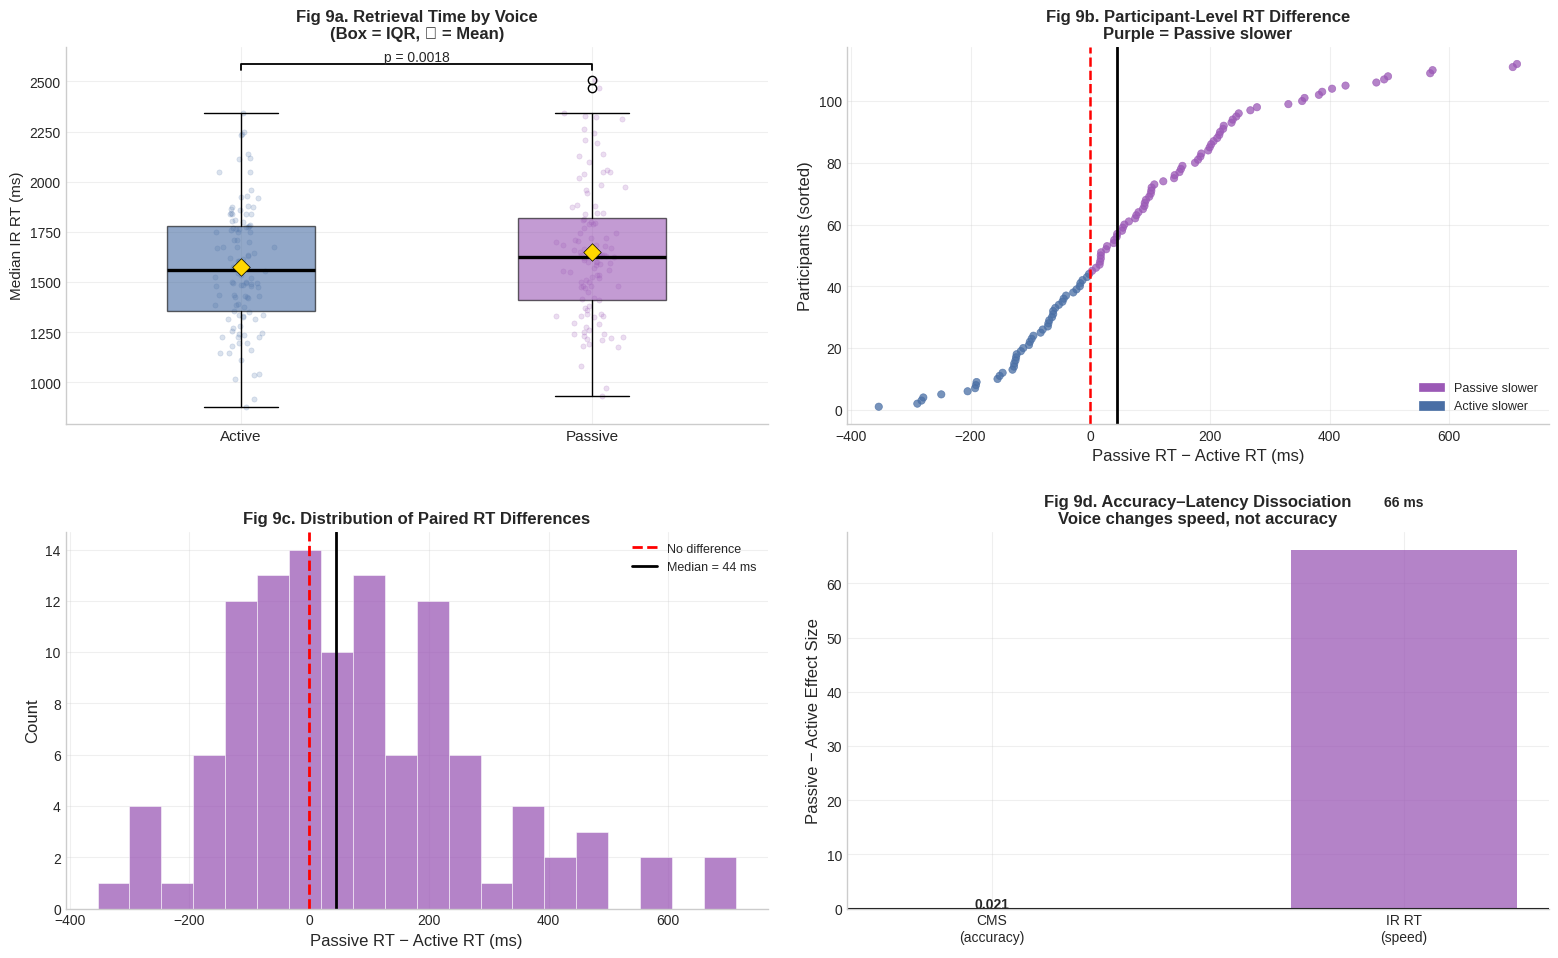

In [64]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')

BLUE   = '#4A6FA5'
PURPLE = '#9B59B6'
GRAY   = '#555555'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax1, ax2, ax3, ax4 = axes.flatten()


for i, vals in enumerate([act_rt, pass_rt], start=1):

    # raw points
    jitter = np.random.normal(i, 0.035, len(vals))
    ax1.scatter(jitter, vals, s=14, alpha=0.20,
                color=BLUE if i == 1 else PURPLE)

# boxplot
bp = ax1.boxplot(
    [act_rt, pass_rt],
    positions=[1, 2],
    widths=0.42,
    patch_artist=True,
    medianprops=dict(color='black', lw=2.4),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, c in zip(bp['boxes'], [BLUE, PURPLE]):
    patch.set_facecolor(c)
    patch.set_alpha(0.60)

# mean dots
means = [np.mean(act_rt), np.mean(pass_rt)]
ax1.scatter([1,2], means, s=80, marker='D', color='gold',
            edgecolor='black', zorder=5)

# significance bracket
ymax = max(np.max(act_rt), np.max(pass_rt))
ax1.plot([1,1,2,2], [ymax+50, ymax+80, ymax+80, ymax+50],
         color='black', lw=1.3)
ax1.text(1.5, ymax+92, f"p = {p_ir_voice:.4f}",
         ha='center', fontsize=10)

ax1.set_xticks([1,2])
ax1.set_xticklabels(['Active', 'Passive'], fontsize=11)
ax1.set_ylabel("Median IR RT (ms)", fontsize=11)
ax1.set_title(
    "Fig 9a. Retrieval Time by Voice\n(Box = IQR, ◆ = Mean)",
    fontsize=12, weight='bold'
)

sorted_diff = np.sort(diffs_rt)
ypos = np.arange(1, len(sorted_diff)+1)

colors = np.where(sorted_diff > 0, PURPLE, BLUE)

ax2.scatter(sorted_diff, ypos, c=colors, s=28, alpha=0.75)

ax2.axvline(0, color='red', ls='--', lw=1.8)
ax2.axvline(np.median(diffs_rt), color='black', lw=2)

ax2.set_xlabel("Passive RT − Active RT (ms)")
ax2.set_ylabel("Participants (sorted)")
ax2.set_title(
    "Fig 9b. Participant-Level RT Difference\nPurple = Passive slower",
    fontsize=12, weight='bold'
)

legend_items = [
    mpatches.Patch(color=PURPLE, label='Passive slower'),
    mpatches.Patch(color=BLUE, label='Active slower')
]
ax2.legend(handles=legend_items, fontsize=9, loc='lower right')
ax3.hist(
    diffs_rt,
    bins=20,
    color=PURPLE,
    alpha=0.75,
    edgecolor='white'
)

ax3.axvline(0, color='red', ls='--', lw=2, label='No difference')
ax3.axvline(np.median(diffs_rt), color='black', lw=2,
            label=f"Median = {np.median(diffs_rt):.0f} ms")

ax3.set_xlabel("Passive RT − Active RT (ms)")
ax3.set_ylabel("Count")
ax3.set_title(
    "Fig 9c. Distribution of Paired RT Differences",
    fontsize=12, weight='bold'
)
ax3.legend(fontsize=9)

cms_diff = cms_passive - cms_active
rt_diff  = np.median(pass_rt) - np.median(act_rt)

metrics = ['CMS\n(accuracy)', 'IR RT\n(speed)']
effects = [cms_diff, rt_diff]

bars = ax4.bar(
    metrics,
    effects,
    color=[GRAY, PURPLE],
    alpha=0.75,
    width=0.55
)

ax4.axhline(0, color='black', lw=1.5)

for bar, val in zip(bars, effects):
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        val + (0.02 if val < 5 else 8),
        f"{val:.3f}" if abs(val) < 5 else f"{val:.0f} ms",
        ha='center',
        fontsize=10,
        weight='bold'
    )

ax4.set_title(
    "Fig 9d. Accuracy–Latency Dissociation\nVoice changes speed, not accuracy",
    fontsize=12, weight='bold'
)

ax4.set_ylabel("Passive − Active Effect Size")

for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.2)
plt.savefig("fig9_report_final.png", dpi=250, bbox_inches='tight')
plt.show()

## H4: Voice Affects Retrieval Speed but Not Retrieval Accuracy (Accuracy–Latency Dissociation)

To test whether sentence voice influences the **speed** of recognition memory retrieval, we analysed **IR reaction times (RTs)** using only correctly recognised repeated trials (Hit trials). For each of the **112 participants**, the median IR RT was computed separately for **Active** and **Passive** sentences, producing a within-subject paired comparison.

Because paired RT differences violated normality assumptions (Shapiro–Wilk), a **Wilcoxon signed-rank test** was used.

### Results

Passive sentences were recognised significantly more slowly than active sentences:

- **Wilcoxon signed-rank:** W = 2193.0  
- **p = 0.0022**  
- **Rank-biserial r = 0.331** (medium effect)

Median paired difference:

- **Passive − Active = +44 ms**

This indicates that participants generally required additional time to recognise passive constructions.

### Interpretation

This result is theoretically important because the earlier voice analysis on CMS showed **no significant accuracy difference** between Active and Passive sentences:

- CMS Voice Effect: non-significant  
- IR RT Voice Effect: significant

Thus, sentence voice affects **retrieval latency (how fast memory is accessed)** rather than **retrieval success (whether memory is correct)**.

Participants remember passive sentences just as accurately, but require longer processing time to confirm recognition.

### Cognitive Explanation

This pattern is consistent with psycholinguistic accounts of passive sentence processing:

- Passive constructions often require **syntactic role re-mapping**
- The thematic agent appears later or indirectly
- Retrieval may involve extra verification steps

Hence, passive voice imposes a **processing cost at retrieval**, even when memory strength remains intact.

### Conclusion

Sentence voice does not reduce memory accuracy, but it slows successful recognition. This reveals an **accuracy–latency dissociation**, where memory strength is preserved while retrieval efficiency declines.

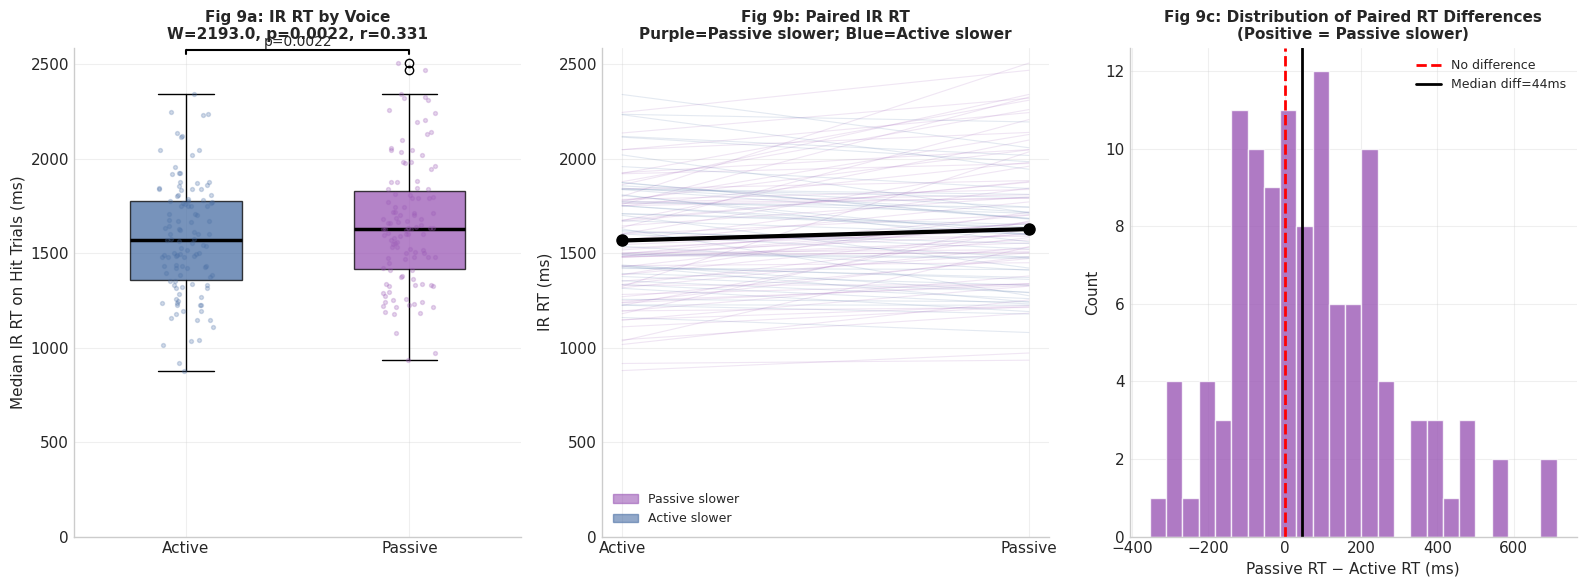

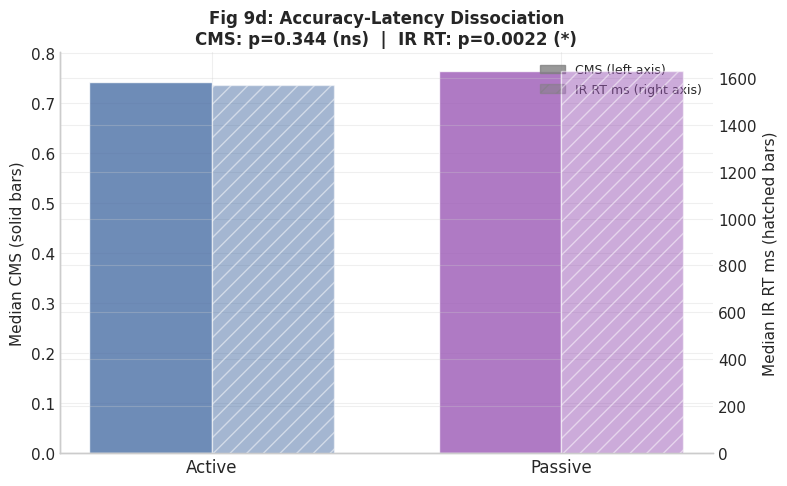

In [59]:
fig, axes_new = plt.subplots(1, 3, figsize=(16, 6))

# ── Boxplot ───────────────────────────────────────────────────────────────────
ax = axes_new[0]
bp = ax.boxplot([act_rt, pass_rt], patch_artist=True, widths=0.5,
                medianprops={'color':'black','lw':2.5})
for patch, color in zip(bp['boxes'], list(VOICE_PAL.values())):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, vals in enumerate([act_rt, pass_rt]):
    ax.scatter(np.full(len(vals),i+1)+np.random.uniform(-0.12,0.12,len(vals)),
               vals, alpha=0.25, s=8, color=list(VOICE_PAL.values())[i], zorder=3)
ax.set_ylim(bottom=0); ax.set_xticks([1,2]); ax.set_xticklabels(['Active','Passive'], fontsize=11)
ax.set_ylabel('Median IR RT on Hit Trials (ms)', fontsize=11)
ax.set_title(f'Fig 9a: IR RT by Voice\nW={W_ir_voice:.1f}, p={p_ir_voice:.4f}, r={r_ir_voice:.3f}',
             fontsize=11, fontweight='bold')
# Significance bracket
if p_ir_voice < 0.05:
    y_br = max(act_rt.max(), pass_rt.max()) + 50
    ax.plot([1,1,2,2],[y_br,y_br+20,y_br+20,y_br], lw=1.5, color='black')
    p_label = f'p={p_ir_voice:.4f}' if p_ir_voice >= 0.001 else 'p<.001'
    ax.text(1.5, y_br+25, p_label, ha='center', va='bottom', fontsize=10)

# ── Paired lines ──────────────────────────────────────────────────────────────
ax2 = axes_new[1]
for a, pv in zip(act_rt, pass_rt):
    ax2.plot([0,1],[a,pv], color='#9B59B6' if pv>a else '#4A6FA5', alpha=0.15, lw=0.8)
ax2.plot([0,1],[np.median(act_rt), np.median(pass_rt)], 'ko-', lw=3, ms=8, zorder=5, label='Median')
ax2.set_ylim(bottom=0); ax2.set_xticks([0,1]); ax2.set_xticklabels(['Active','Passive'], fontsize=11)
ax2.set_ylabel('IR RT (ms)', fontsize=11)
ax2.set_title(f'Fig 9b: Paired IR RT\nPurple=Passive slower; Blue=Active slower',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
purple_p = mpatches.Patch(color='#9B59B6', alpha=0.6, label='Passive slower')
blue_p   = mpatches.Patch(color='#4A6FA5', alpha=0.6, label='Active slower')
ax2.legend(handles=[purple_p, blue_p], fontsize=9)

# ── Histogram of differences + dissociation summary ──────────────────────────
ax3 = axes_new[2]
ax3.hist(diffs_rt, bins=25, color='#9B59B6', edgecolor='white', alpha=0.8)
ax3.axvline(0, color='red', lw=2, ls='--', label='No difference')
ax3.axvline(np.median(diffs_rt), color='black', lw=2, label=f'Median diff={np.median(diffs_rt):.0f}ms')
ax3.set_ylim(bottom=0)
ax3.set_xlabel('Passive RT − Active RT (ms)', fontsize=11)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Fig 9c: Distribution of Paired RT Differences\n(Positive = Passive slower)',
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig9_voice_ir_rt.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Dissociation summary plot ─────────────────────────────────────────────────
fig2, ax_dis = plt.subplots(figsize=(8, 5))
categories = ['Active', 'Passive']
cms_vals = [np.median(df[df['voice']==v]['corr_memorability'].dropna()) for v in categories]
rt_normalized = [np.median(act_rt)/np.median(act_rt), np.median(pass_rt)/np.median(act_rt)]

x_pos = np.array([0, 1])
width = 0.35
bars1 = ax_dis.bar(x_pos - width/2, cms_vals, width, label='Median CMS',
                   color=['#4A6FA5','#9B59B6'], alpha=0.8, edgecolor='white')
ax_dis2 = ax_dis.twinx()
bars2 = ax_dis2.bar(x_pos + width/2, [np.median(act_rt), np.median(pass_rt)], width,
                    label='Median IR RT (ms)', color=['#4A6FA5','#9B59B6'], alpha=0.5,
                    edgecolor='white', hatch='//')
ax_dis.set_ylim(bottom=0); ax_dis2.set_ylim(bottom=0)
ax_dis.set_xticks(x_pos); ax_dis.set_xticklabels(categories, fontsize=12)
ax_dis.set_ylabel('Median CMS (solid bars)', fontsize=11)
ax_dis2.set_ylabel('Median IR RT ms (hatched bars)', fontsize=11)
ax_dis.set_title('Fig 9d: Accuracy-Latency Dissociation\n'
                 f'CMS: p={p_voice:.3f} (ns)  |  IR RT: p={p_ir_voice:.4f} (*)',
                 fontsize=12, fontweight='bold')
lines = [mpatches.Patch(color='gray', alpha=0.8, label='CMS (left axis)'),
         mpatches.Patch(color='gray', alpha=0.5, hatch='//', label='IR RT ms (right axis)')]
ax_dis.legend(handles=lines, fontsize=9)
plt.tight_layout()
plt.savefig('fig9d_dissociation.png', dpi=150, bbox_inches='tight')
plt.show()
